# Preprocesamiento y filtrado de las trayectorias

Este notebook prepara el panel de trayectorias de artistas para la etapa de clusterización y segmentación. Cada paso aplica una herramienta de la materia sobre los datos reales: el teorema del muestreo para validar la frecuencia mensual, interpolación para los faltantes, pruebas de estacionaridad para fundamentar la transformación, media móvil y filtrado en el dominio de la frecuencia para el suavizado, y una derivada FIR para medir el crecimiento mensual.

**Entrada:** el panel exportado por el notebook de Chartmetric (sección 16), en formato largo: un registro por artista, variable y mes.
**Salida:** el mismo panel con las series limpias, imputadas, transformadas y suavizadas.

In [1]:
# PAQUETES

library(data.table)
library(tseries)    # adf.test y kpss.test
library(grid)
library(gridExtra)  # tablas exportables como imagen

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



## 1. Configuración y carga

In [2]:
# ============================================================
# CONFIGURACION
# ============================================================

ARCHIVO_PANEL_LONG <- "artistas_ST_1098de1510_top5000_22_26_na_long.csv"

FIGURES_DIR <- "figuras"
dir.create(FIGURES_DIR, showWarnings = FALSE, recursive = TRUE)

VARIABLES_PANEL <- c(
  spotify_followers           = "Seguidores en Spotify",
  instagram_followers         = "Seguidores en Instagram",
  spotify_playlist_count      = "Playlists en Spotify",
  youtube_channel_subscribers = "Suscriptores en YouTube",
  youtube_playlist_count      = "Playlists en YouTube"
)

# Variables de audiencia acumulada: no pueden caer a la mitad de
# un mes a otro, por eso solo en ellas se buscan picos aislados y
# cambios de nivel (bloque 4). Las cuentas de playlists suben y bajan.
VARIABLES_STOCK_AUDIENCIA <- c(
  "spotify_followers",
  "instagram_followers",
  "youtube_channel_subscribers"
)

# Salto mensual (en log1p) que define un error de la fuente:
# log(2) es duplicarse o caer a la mitad de un mes a otro
UMBRAL_SALTO_FUENTE <- log(2)

# Quiebre comun de la fuente (bloque 4): mes en que al menos 2/3
# de los artistas cambian mas de 10 % en el mismo sentido
PROPORCION_QUIEBRE_COMUN <- 2 / 3
CAMBIO_MINIMO_QUIEBRE_COMUN <- log(1.1)

# Transformacion de las series (bloque 5). Opciones:
# "log1p_centrado" (elegida), "log1p_estandarizado",
# "log1p_desde_inicio", "sin_transformar"
TRANSFORMACION <- "log1p_centrado"

# Medias moviles centradas, en meses (bloque 7): suavizado con
# ventana impar simple; tendencia con media movil 2x12 (13 meses,
# extremos a mitad de peso), el filtro de decompose() mensual
VENTANAS_MEDIA_MOVIL <- c(
  suavizado = 3,
  tendencia = 12
)

# Armonicos que conserva el pasa-bajos FFT, ademas de la
# frecuencia cero (bloque 8)
BANDA_FILTRO_PASA_BAJOS <- 6

# Artistas ilustrativos del suavizado (bloque 7): uno por tercil
# de cm_artist_rank, de reconocimiento publico y sin meses
# imputados en ninguna variable
ARTISTAS_ILUSTRATIVOS <- c(
  rank_alto  = 206907L,   # TINI
  rank_medio = 276L,      # Megadeth
  rank_bajo  = 2456L      # Abel Pintos
)

# Variable para los ejemplos de una sola serie (bloques 7 y 8)
VARIABLE_ILUSTRATIVA <- "spotify_followers"

# Artistas fijos de la figura de presentacion: trayectoria
# estable y crecimiento explosivo en 2023, ambos del decil 1
ARTISTAS_FIGURA_PRESENTACION <- c(
  3648L,      # Ed Sheeran
  4251908L    # Peso Pluma
)

# Series diarias del piloto de extraccion, para verificar el
# muestreo mensual (bloque 3), y su correspondencia con el panel
ARCHIVO_DIARIO_PILOTO <- "chartmetric_pilotos/chartmetric_raw_long.rds"

FUENTE_DIARIA_VARIABLES <- data.table(
  source   = c("spotify", "instagram", "youtube_channel"),
  metric   = c("followers", "followers", "subscribers"),
  variable = VARIABLES_STOCK_AUDIENCIA
)

ARCHIVO_PANEL_PREPROCESADO <- sub(
  "_na_long\\.csv$",
  paste0("_preprocesado_", TRANSFORMACION, "_long.csv"),
  ARCHIVO_PANEL_LONG
)

# Estilo grafico comun. Cada color tiene un solo significado en
# todo el notebook:
#   PALETA_ARTISTAS: un color por artista (figuras 1 y 4)
#   COLOR_SERIE_BASE: dato de partida (serie cruda, transformada o diaria)
#   COLOR_RESULTADO: serie que queda despues de corregir, imputar o filtrar
#   COLOR_ALERTA: problema detectado o alternativa descartada
#   COLOR_MEDIA_MOVIL y COLOR_TENDENCIA: los dos filtros de media movil
#   COLOR_REFERENCIA: lineas de referencia (Nyquist, corte en 0,7)
COLOR_FONDO <- "#FFFFFF"
COLOR_GRILLA <- "#E6E0D5"
PALETA_ARTISTAS <- c("#1982C4", "#F04A50", "#6A4C93")
COLOR_SERIE_BASE <- "#B8B8B8"
COLOR_RESULTADO <- "#1D1E2C"
COLOR_ALERTA <- "#E4007C"
COLOR_MEDIA_MOVIL <- "#00A878"
COLOR_TENDENCIA <- "#FF7A00"
COLOR_REFERENCIA <- "#6B6B6B"

ARCHIVO_PANEL_PREPROCESADO

[1] "artistas_ST_1098de1510_top5000_22_26_preprocesado_log1p_centrado_long.csv"

In [3]:
# ============================================================
# CARGA DEL PANEL EN FORMATO LARGO
# Una sola tabla, panel_long, que los bloques siguientes
# completan por referencia con una columna por etapa
# ============================================================

panel_long <- fread(
  ARCHIVO_PANEL_LONG,
  select = c(
    "artist_id", "artist_name", "cm_artist_rank", "decil_marco",
    "variable", "month", "value", "tipo_dato", "interpolated"
  )
)

setnames(panel_long, "value", "valor_crudo")
panel_long[, month := as.Date(month)]
setkey(panel_long, artist_id, variable, month)

MESES_PANEL <- sort(unique(panel_long$month))
N_MESES_PANEL <- length(MESES_PANEL)
panel_long[, mes_indice := match(month, MESES_PANEL)]

artistas_panel <- unique(
  panel_long[, .(artist_id, artist_name, cm_artist_rank, decil_marco)]
)

cat(
  "Artistas:", nrow(artistas_panel), "\n",
  "Variables:", uniqueN(panel_long$variable), "\n",
  "Meses:", N_MESES_PANEL, "(", format(MESES_PANEL[1]), "a", format(MESES_PANEL[N_MESES_PANEL]), ")\n"
)

Artistas: 1098 
 Variables: 5 
 Meses: 49 ( 2022-03-01 a 2026-03-01 )


In [4]:
# ------------------------------------------------------------
# CONTROL: grilla completa (49 meses por artista y variable) y
# celdas sin dato por variable segun su ubicacion en la serie
# ------------------------------------------------------------

stopifnot(
  panel_long[, .N, by = .(artist_id, variable)][, all(N == N_MESES_PANEL)],
  setequal(unique(panel_long$variable), names(VARIABLES_PANEL))
)

dcast(
  panel_long[, .N, by = .(variable, tipo_dato)][, pct := round(100 * N / sum(N), 2), by = variable],
  variable ~ tipo_dato,
  value.var = "pct",
  fill = 0
)

variable,hueco_interno,observado,previo_primer_dato
<chr>,<dbl>,<dbl>,<dbl>
instagram_followers,0.91,98.93,0.16
spotify_followers,0.06,99.94,0.00
spotify_playlist_count,0.00,100.00,0.00
youtube_channel_subscribers,0.09,99.63,0.28
youtube_playlist_count,0.47,99.10,0.43


## 2. Las series crudas

Cada artista es una trayectoria de cinco variables con frecuencia mensual. Ed Sheeran (trayectoria consolidada) y Peso Pluma (crecimiento explosivo en 2023) ilustran el problema central: las variables difieren en órdenes de magnitud entre sí y entre artistas, y por eso necesitan una transformación antes de comparar formas.

In [5]:
# ============================================================
# FUNCIONES GRAFICAS COMUNES
# ============================================================

MARCAS_X_FIGURA <- seq(MESES_PANEL[1], MESES_PANEL[N_MESES_PANEL], by = "year")

# Muestra el grafico en el notebook y lo guarda en FIGURES_DIR
guardar_figura <- function(nombre_archivo, funcion_grafico, ancho, alto) {
  options(repr.plot.width = ancho / 200, repr.plot.height = alto / 200)
  funcion_grafico()
  # se dibuja en un archivo temporal y se escriben sus bytes sobre el
  # destino: evita fallas si el PNG anterior esta abierto en un visor
  # (file.copy no puede reemplazarlo en Windows)
  archivo_temporal <- tempfile(fileext = ".png")
  png(archivo_temporal, width = ancho, height = alto, res = 200)
  funcion_grafico()
  invisible(dev.off())
  bytes_figura <- readBin(archivo_temporal, "raw", file.size(archivo_temporal))
  # hasta cinco intentos: un visor que relee el archivo lo bloquea
  # por un instante
  guardado <- FALSE
  for (intento in 1:5) {
    guardado <- tryCatch({
      writeBin(bytes_figura, file.path(FIGURES_DIR, nombre_archivo))
      TRUE
    }, error = function(e) FALSE, warning = function(w) FALSE)
    if (guardado) break
    Sys.sleep(1)
  }
  if (!guardado) warning("No se pudo guardar ", nombre_archivo, ": el archivo puede estar abierto")
}

# Etiquetas del eje y en millones o miles, sin notacion cientifica
etiqueta_eje_magnitud <- function(x) {
  numero <- function(v) formatC(v, format = "fg", digits = 3, big.mark = ".", decimal.mark = ",")
  ifelse(x >= 1e6, paste0(numero(x / 1e6), " M"),
         ifelse(x >= 1e3, paste0(numero(x / 1e3), " mil"), numero(x)))
}

# Nombre de variable dentro de una frase: solo la inicial en minuscula
en_minuscula_inicial <- function(texto) paste0(tolower(substr(texto, 1, 1)), substring(texto, 2))

# Lienzo vacio con eje temporal del panel y grilla horizontal
abrir_lienzo <- function(rango_y, titulo, escala_log = FALSE, tamanio_titulo = 1.1) {
  plot(
    range(MESES_PANEL), rango_y,
    type = "n", log = if (escala_log) "y" else "",
    xlab = "", ylab = "", xaxt = "n", yaxt = "n", bty = "n",
    main = titulo, font.main = 1, cex.main = tamanio_titulo
  )
  axis(1, at = MARCAS_X_FIGURA, labels = paste("mar", format(MARCAS_X_FIGURA, "%Y")),
       col = NA, col.ticks = "#B8B0A2")
  marcas_y <- axTicks(2)
  axis(2, at = marcas_y, col = NA, col.ticks = NA,
       labels = if (max(abs(marcas_y)) >= 1e3) etiqueta_eje_magnitud(marcas_y) else format(marcas_y, decimal.mark = ","))
  abline(h = marcas_y, col = COLOR_GRILLA)
}

# Las cinco variables, un panel por variable, para los artistas
# de la figura de presentacion; columna_valor elige la etapa
grafico_cinco_variables <- function(columna_valor, titulo, escala_log) {

  series_figura <- panel_long[artist_id %in% ARTISTAS_FIGURA_PRESENTACION]

  # con 5 paneles en fila R reduce los textos a 2/3: el titulo de
  # cada panel se agranda para compensar
  par(mfrow = c(1, 5), bg = COLOR_FONDO, mar = c(3, 4.2, 3.6, 1),
      oma = c(0, 0, 4.5, 0), las = 1, cex.axis = 0.9)

  for (variable_figura in names(VARIABLES_PANEL)) {

    series_variable <- series_figura[variable == variable_figura]

    abrir_lienzo(range(series_variable[[columna_valor]], na.rm = TRUE),
                 VARIABLES_PANEL[[variable_figura]], escala_log, tamanio_titulo = 2)

    for (i in seq_along(ARTISTAS_FIGURA_PRESENTACION)) {
      serie_artista <- series_variable[artist_id == ARTISTAS_FIGURA_PRESENTACION[i]]
      # meses imputados (si ya existe la marca) en linea punteada
      # fina, observados en linea llena
      valores_observados <- serie_artista[[columna_valor]]
      if ("imputado" %in% names(serie_artista)) valores_observados[serie_artista$imputado] <- NA
      lines(serie_artista$month, serie_artista[[columna_valor]], col = PALETA_ARTISTAS[i], lwd = 1.5, lty = 3)
      lines(serie_artista$month, valores_observados, col = PALETA_ARTISTAS[i], lwd = 2.5)
    }
  }

  mtext(titulo, side = 3, outer = TRUE, line = 2.6, cex = 1.1)

  par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
  plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
  legend(
    "top",
    legend = artistas_panel[match(ARTISTAS_FIGURA_PRESENTACION, artist_id), artist_name],
    col = PALETA_ARTISTAS[seq_along(ARTISTAS_FIGURA_PRESENTACION)],
    lwd = 2.5, horiz = TRUE, bty = "n", inset = c(0, 0.075), cex = 1.05
  )
}

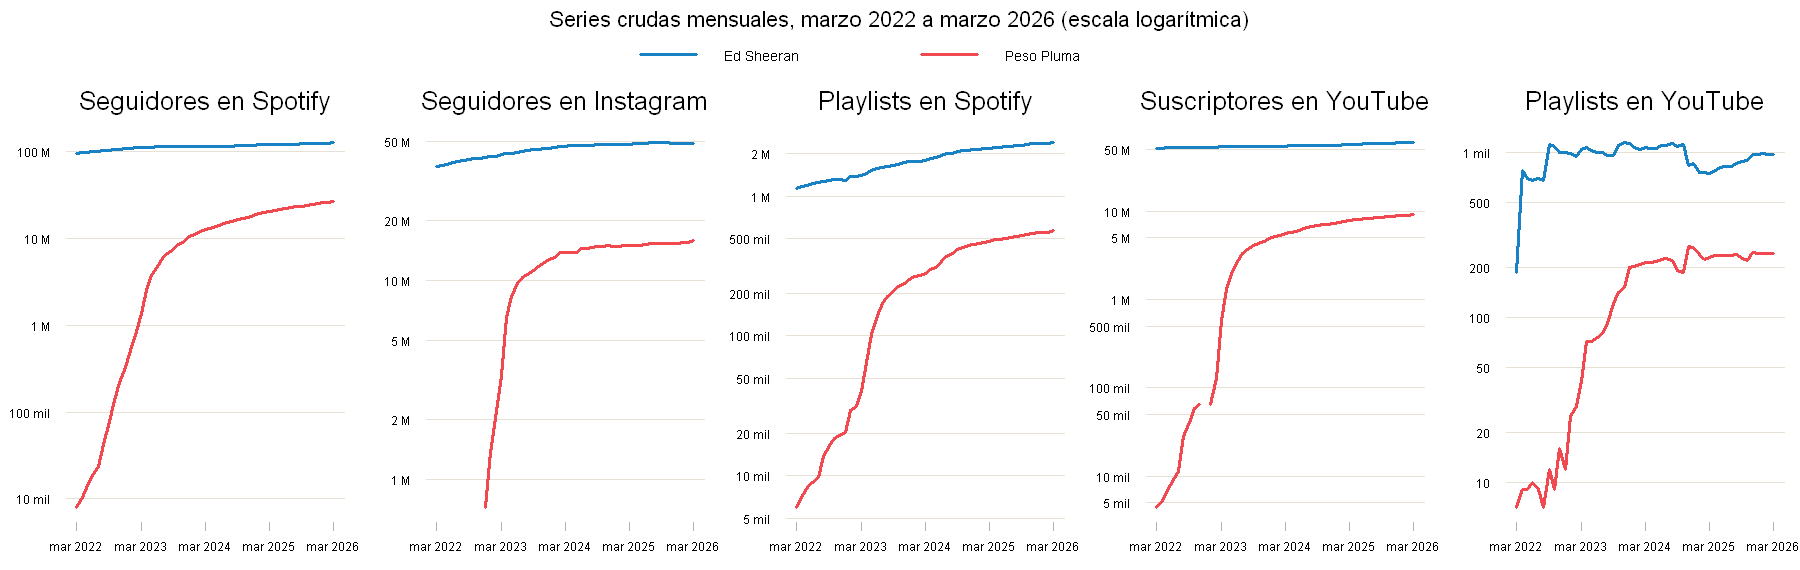

In [6]:
# ============================================================
# FIGURA 1: series crudas de los dos artistas de presentacion
# ============================================================

guardar_figura(
  "prepro_01_series_crudas.png",
  function() grafico_cinco_variables(
    "valor_crudo",
    "Series crudas mensuales, marzo 2022 a marzo 2026 (escala logarítmica)",
    escala_log = TRUE
  ),
  ancho = 3000, alto = 950
)

**Estadística descriptiva en el dominio del tiempo.** Los parámetros estadísticos de la clase (media, desvío, rango, histograma) se calculan sobre las muestras de una serie a lo largo del tiempo. Con un panel de artistas, el equivalente es calcularlos mes a mes entre artistas: la mediana de cada mes forma la trayectoria de un artista típico, y los percentiles muestran cuánto se apartan los demás. Se usan los valores crudos, antes de cualquier limpieza o filtro.


In [7]:
# ============================================================
# ESTADISTICOS DESCRIPTIVOS POR VARIABLE Y MES: media, mediana,
# desvio y percentiles entre artistas, valores crudos
# ============================================================

descriptivos_mensuales <- panel_long[
  !is.na(valor_crudo),
  .(artistas = .N,
    media = mean(valor_crudo),
    mediana = median(valor_crudo),
    desvio = sd(valor_crudo),
    p10 = quantile(valor_crudo, 0.10),
    p25 = quantile(valor_crudo, 0.25),
    p75 = quantile(valor_crudo, 0.75),
    p90 = quantile(valor_crudo, 0.90)),
  keyby = .(variable, month)
]

# Control: un registro por variable y mes, y vista del primer y
# el ultimo mes
stopifnot(descriptivos_mensuales[, .N, by = variable][, all(N == N_MESES_PANEL)])

descriptivos_mensuales[month %in% range(MESES_PANEL), .(variable, month, artistas, media = round(media), mediana = round(mediana))]


variable,month,artistas,media,mediana
<chr>,<date>,<int>,<dbl>,<dbl>
instagram_followers,2022-03-01,1070,3387635,664542
instagram_followers,2026-03-01,1098,4430324,1107254
spotify_followers,2022-03-01,1095,2304155,977754
spotify_followers,2026-03-01,1098,4299954,1789428
spotify_playlist_count,2022-03-01,1096,115734,67997
spotify_playlist_count,2026-03-01,1098,298805,191254
youtube_channel_subscribers,2022-03-01,1059,2188136,650000
youtube_channel_subscribers,2026-03-01,1098,2837577,941803
youtube_playlist_count,2022-03-01,897,10,5


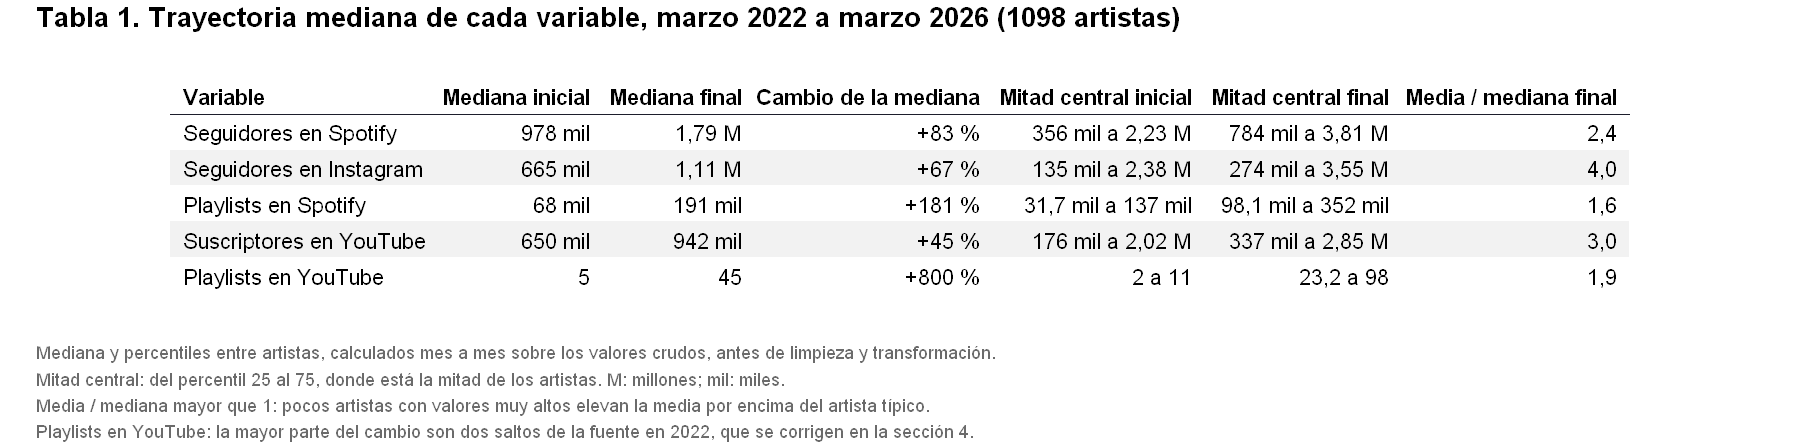

In [8]:
# ============================================================
# TABLA 1: trayectoria mediana de cada variable, inicio y final
# del panel (imagen para presentaciones) y CSV con todos los meses
# ============================================================

MES_INICIO_PANEL <- MESES_PANEL[1]
MES_FINAL_PANEL <- MESES_PANEL[N_MESES_PANEL]
N_ARTISTAS_DESCRIPTIVA <- uniqueN(panel_long$artist_id)

formato_porcentaje <- function(x) paste0(ifelse(x > 0, "+", ""), trimws(format(round(x), big.mark = ".", decimal.mark = ",")), " %")
formato_rango <- function(desde, hasta) paste(trimws(etiqueta_eje_magnitud(desde)), "a", trimws(etiqueta_eje_magnitud(hasta)))

inicio_final <- merge(
  descriptivos_mensuales[month == MES_INICIO_PANEL],
  descriptivos_mensuales[month == MES_FINAL_PANEL],
  by = "variable", suffixes = c("_inicio", "_final")
)[match(names(VARIABLES_PANEL), variable)]

tabla_1_descriptiva <- inicio_final[
  ,
  .(`Variable` = unname(VARIABLES_PANEL[variable]),
    `Mediana inicial` = trimws(etiqueta_eje_magnitud(mediana_inicio)),
    `Mediana final` = trimws(etiqueta_eje_magnitud(mediana_final)),
    `Cambio de la mediana` = formato_porcentaje(100 * (mediana_final / mediana_inicio - 1)),
    `Mitad central inicial` = formato_rango(p25_inicio, p75_inicio),
    `Mitad central final` = formato_rango(p25_final, p75_final),
    `Media / mediana final` = format(round(media_final / mediana_final, 1), decimal.mark = ","))
]

titulo_tabla_1 <- paste0(
  "Tabla 1. Trayectoria mediana de cada variable, ", format(MES_INICIO_PANEL, "%B %Y"),
  " a ", format(MES_FINAL_PANEL, "%B %Y"), " (", N_ARTISTAS_DESCRIPTIVA, " artistas)"
)

nota_tabla_1 <- paste(
  "Mediana y percentiles entre artistas, calculados mes a mes sobre los valores crudos, antes de limpieza y transformación.",
  "Mitad central: del percentil 25 al 75, donde está la mitad de los artistas. M: millones; mil: miles.",
  "Media / mediana mayor que 1: pocos artistas con valores muy altos elevan la media por encima del artista típico.",
  "Playlists en YouTube: la mayor parte del cambio son dos saltos de la fuente en 2022, que se corrigen en la sección 4.",
  sep = "\n"
)

tema_tabla_1 <- ttheme_minimal(
  base_size = 13,
  core = list(
    bg_params = list(fill = c(COLOR_FONDO, "#F2F2F2"), col = NA),
    fg_params = list(hjust = 1, x = 0.95)
  ),
  colhead = list(
    fg_params = list(fontface = "bold", hjust = 1, x = 0.95),
    bg_params = list(fill = COLOR_FONDO, col = NA)
  )
)

grob_tabla_1 <- tableGrob(tabla_1_descriptiva, rows = NULL, theme = tema_tabla_1)

# primera columna (nombre de la variable) alineada a la izquierda
for (indice in which(grob_tabla_1$layout$l == 1 & grob_tabla_1$layout$name %in% c("core-fg", "colhead-fg"))) {
  grob_tabla_1$grobs[[indice]]$hjust <- 0
  grob_tabla_1$grobs[[indice]]$x <- unit(0.05, "npc")
}

# linea bajo el encabezado
grob_tabla_1 <- gtable::gtable_add_grob(
  grob_tabla_1,
  segmentsGrob(x0 = unit(0, "npc"), x1 = unit(1, "npc"), y0 = unit(0, "npc"), y1 = unit(0, "npc"),
               gp = gpar(col = COLOR_RESULTADO, lwd = 1.5)),
  t = 1, l = 1, r = ncol(grob_tabla_1)
)

grob_tabla_1_completa <- arrangeGrob(
  grob_tabla_1,
  top = textGrob(titulo_tabla_1, x = 0.02, hjust = 0, gp = gpar(fontsize = 16, fontface = "bold")),
  bottom = textGrob(nota_tabla_1, x = 0.02, hjust = 0, gp = gpar(fontsize = 11, col = COLOR_REFERENCIA))
)

guardar_figura(
  "tabla_01_descriptiva.png",
  function() {
    grid.newpage()
    grid.rect(gp = gpar(fill = COLOR_FONDO, col = NA))
    grid.draw(grob_tabla_1_completa)
  },
  ancho = 3000, alto = 740
)

# CSV con todos los meses y estadisticos, sin redondear
fwrite(
  descriptivos_mensuales[, .(variable, nombre = unname(VARIABLES_PANEL[variable]), month, artistas,
                             media, mediana, desvio_estandar = desvio, p10, p25, p75, p90)],
  file.path(FIGURES_DIR, "tabla_01_descriptiva.csv")
)


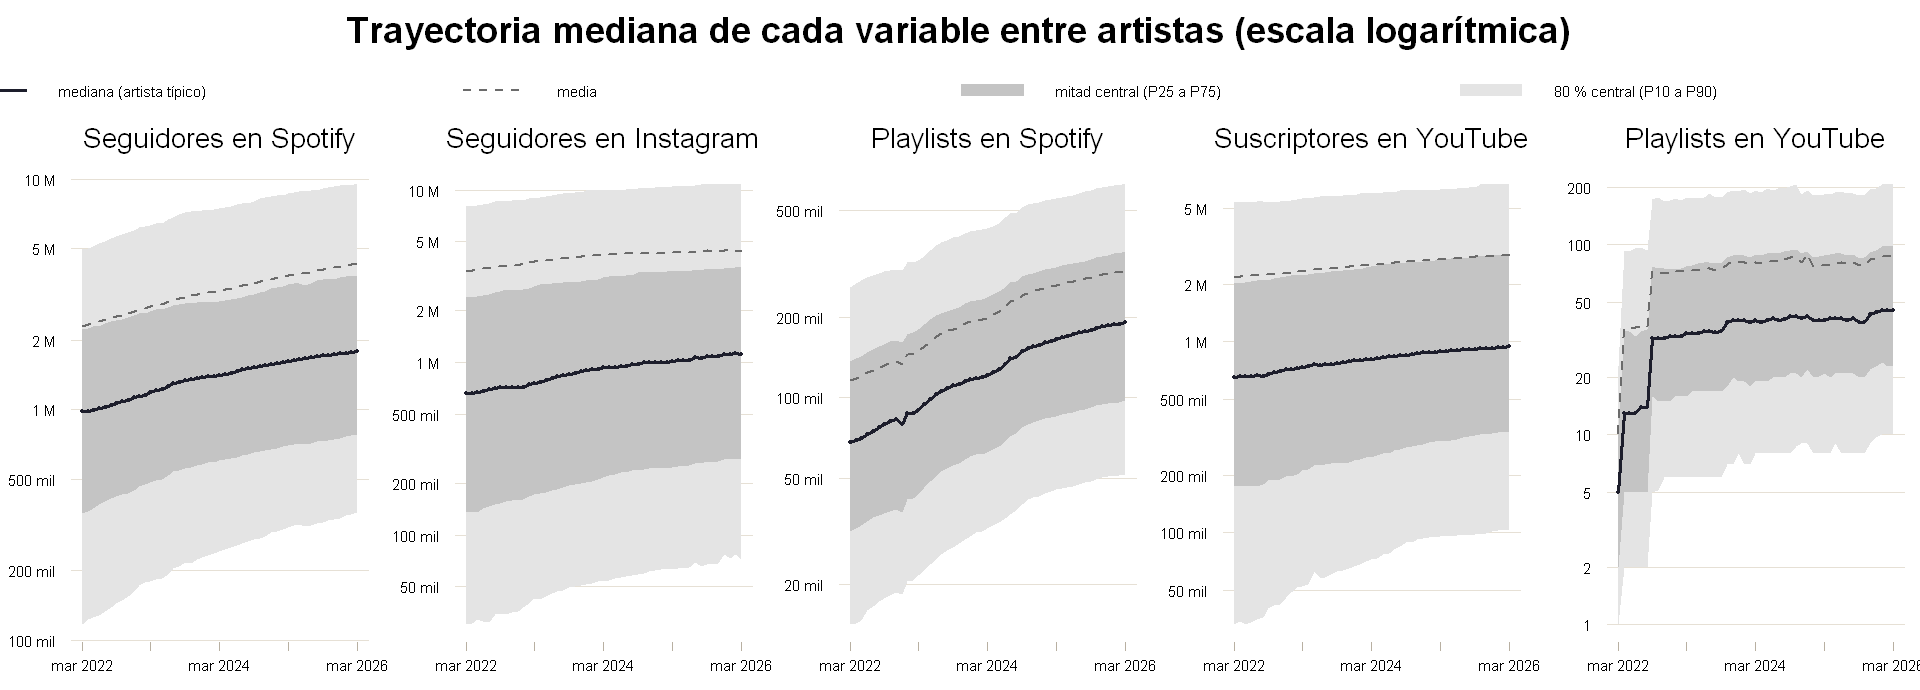

In [9]:
# ============================================================
# FIGURA 1b: trayectoria mediana de cada variable entre artistas,
# con la mitad central (P25 a P75), el 80 % central (P10 a P90)
# y la media
# ============================================================

TAMANIO_TITULO_DESCRIPTIVA <- 1.8
TAMANIO_TITULO_PANEL_DESCRIPTIVA <- 2.1
TAMANIO_TEXTO_DESCRIPTIVA <- 1.1

COLOR_BANDA_P10_P90 <- "#E4E4E4"
COLOR_BANDA_P25_P75 <- "#C4C4C4"

banda_entre <- function(meses, desde, hasta, color) {
  polygon(c(meses, rev(meses)), c(desde, rev(hasta)), col = color, border = NA)
}

grafico_trayectoria_mediana <- function() {

  par(mfrow = c(1, length(VARIABLES_PANEL)), bg = COLOR_FONDO, mar = c(3, 4.5, 3, 1),
      oma = c(0, 0, 7.5, 0), las = 1, cex.axis = TAMANIO_TEXTO_DESCRIPTIVA)

  for (variable_figura in names(VARIABLES_PANEL)) {

    estadisticos_variable <- descriptivos_mensuales[variable_figura]

    abrir_lienzo(range(estadisticos_variable[, .(p10, p90, media)]), "", escala_log = TRUE)
    title(VARIABLES_PANEL[[variable_figura]], font.main = 1, cex.main = TAMANIO_TITULO_PANEL_DESCRIPTIVA, line = 1.2)

    banda_entre(estadisticos_variable$month, estadisticos_variable$p10, estadisticos_variable$p90, COLOR_BANDA_P10_P90)
    banda_entre(estadisticos_variable$month, estadisticos_variable$p25, estadisticos_variable$p75, COLOR_BANDA_P25_P75)
    lines(estadisticos_variable$month, estadisticos_variable$media, col = COLOR_REFERENCIA, lwd = 2, lty = 2)
    lines(estadisticos_variable$month, estadisticos_variable$mediana, col = COLOR_RESULTADO, lwd = 3)
    points(estadisticos_variable$month, estadisticos_variable$mediana, pch = 19, col = COLOR_RESULTADO, cex = 0.7)
  }

  mtext("Trayectoria mediana de cada variable entre artistas (escala logarítmica)",
        side = 3, outer = TRUE, line = 4.6, font = 2, cex = TAMANIO_TITULO_DESCRIPTIVA)

  par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
  plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
  par(lend = 1)  # extremos rectos: las muestras de las bandas no invaden el texto
  legend("top", ncol = 4, bty = "n", inset = c(0, 0.11), cex = TAMANIO_TEXTO_DESCRIPTIVA, x.intersp = 1,
         legend = c("mediana (artista típico)", "media", "mitad central (P25 a P75)", "80 % central (P10 a P90)"),
         col = c(COLOR_RESULTADO, COLOR_REFERENCIA, COLOR_BANDA_P25_P75, COLOR_BANDA_P10_P90),
         lwd = c(3, 2, 10, 10), lty = c(1, 2, 1, 1), pch = c(19, NA, NA, NA), seg.len = 2)
}

guardar_figura("prepro_01b_descriptiva.png", grafico_trayectoria_mediana, ancho = 3200, alto = 1150)


La mediana crece en las cinco variables y, en escala logarítmica, las bandas avanzan casi paralelas a ella: la distancia relativa entre artistas chicos y grandes se mantiene durante los cuatro años. La media queda siempre por encima de la mediana porque la asimetría que generan los artistas masivos no desaparece con el tiempo, y esa es la razón para trabajar en escala logarítmica (bloque 5). Las playlists de YouTube muestran dos saltos en 2022 que no son crecimiento sino cambios de la fuente; se corrigen con el empalme del bloque 4.


## 3. Muestreo mensual

El panel es mensual porque toma el último dato diario de cada mes. Con 12 muestras por año, el teorema del muestreo fija el límite (frecuencia de Nyquist) en 6 ciclos por año: una oscilación más rápida no desaparece, se pliega sobre frecuencias más bajas (alias). Tomar un día por mes es submuestrear sin el pasa-bajos previo que recomienda la clase de interpolación, así que verificamos cuánta energía tienen las series diarias por encima de ese límite.

Se usan las series diarias de las variables de audiencia para los artistas del panel que formaron parte del piloto de extracción. Las fechas faltantes se completan por interpolación lineal para tener un muestreo diario uniforme, y a cada serie se le resta su recta de tendencia antes de la FFT.

In [10]:
# ============================================================
# SERIES DIARIAS: MUESTREO UNIFORME Y ESPECTRO
# ============================================================

DIAS_PANEL <- seq(MESES_PANEL[1], seq(MESES_PANEL[N_MESES_PANEL], by = "month", length.out = 2)[2] - 1, by = "day")
N_DIAS_PANEL <- length(DIAS_PANEL)
FRECUENCIA_NYQUIST_MENSUAL <- 12 / 2    # ciclos por anio

serie_diaria <- readRDS(ARCHIVO_DIARIO_PILOTO)[
  FUENTE_DIARIA_VARIABLES, on = .(source, metric), nomatch = NULL
][
  , `:=`(artist_id = as.integer(artist_id), fecha = as.Date(timestamp))
][
  artist_id %in% artistas_panel$artist_id & fecha %between% range(DIAS_PANEL) & !is.na(value),
  .(valor = value[.N]),
  keyby = .(artist_id, variable, fecha)
]

serie_diaria_uniforme <- serie_diaria[
  ,
  .(fecha = DIAS_PANEL,
    log_valor = approx(as.numeric(fecha), log1p(valor), xout = as.numeric(DIAS_PANEL), rule = 2)$y),
  by = .(artist_id, variable)
]

armonicos_diarios <- seq_len(N_DIAS_PANEL %/% 2)

espectro_diario <- serie_diaria_uniforme[
  ,
  .(ciclos_por_anio = armonicos_diarios * 365.25 / N_DIAS_PANEL,
    potencia = Mod(fft(residuals(lm(log_valor ~ seq_along(log_valor)))))[armonicos_diarios + 1]^2),
  by = .(artist_id, variable)
]

# Dos versiones mensuales de la misma serie diaria: el ultimo dia
# (la del panel) y el promedio del mes (pasa-bajos antes de submuestrear)
muestreo_mensual_comparado <- serie_diaria_uniforme[
  ,
  .(ultimo_dia = log_valor[.N], promedio_mes = mean(log_valor)),
  by = .(artist_id, variable, month = as.Date(format(fecha, "%Y-%m-01")))
]

resumen_muestreo <- espectro_diario[
  ,
  .(pct_energia = 100 * sum(potencia[ciclos_por_anio > FRECUENCIA_NYQUIST_MENSUAL]) / sum(potencia)),
  by = .(artist_id, variable)
][
  ,
  .(series = .N,
    pct_energia_sobre_nyquist_mediana = round(median(pct_energia), 2),
    pct_energia_sobre_nyquist_p90 = round(quantile(pct_energia, 0.9), 2)),
  by = variable
][
  muestreo_mensual_comparado[
    , .(dif_ultimo_dia_vs_promedio_pct = round(100 * median(abs(ultimo_dia - promedio_mes)), 2)), by = variable
  ],
  on = "variable"
]

resumen_muestreo

variable,series,pct_energia_sobre_nyquist_mediana,pct_energia_sobre_nyquist_p90,dif_ultimo_dia_vs_promedio_pct
<chr>,<int>,<dbl>,<dbl>,<dbl>
instagram_followers,124,1.05,2.92,0.26
spotify_followers,124,0.98,3.70,0.52
youtube_channel_subscribers,124,1.64,8.28,0.31


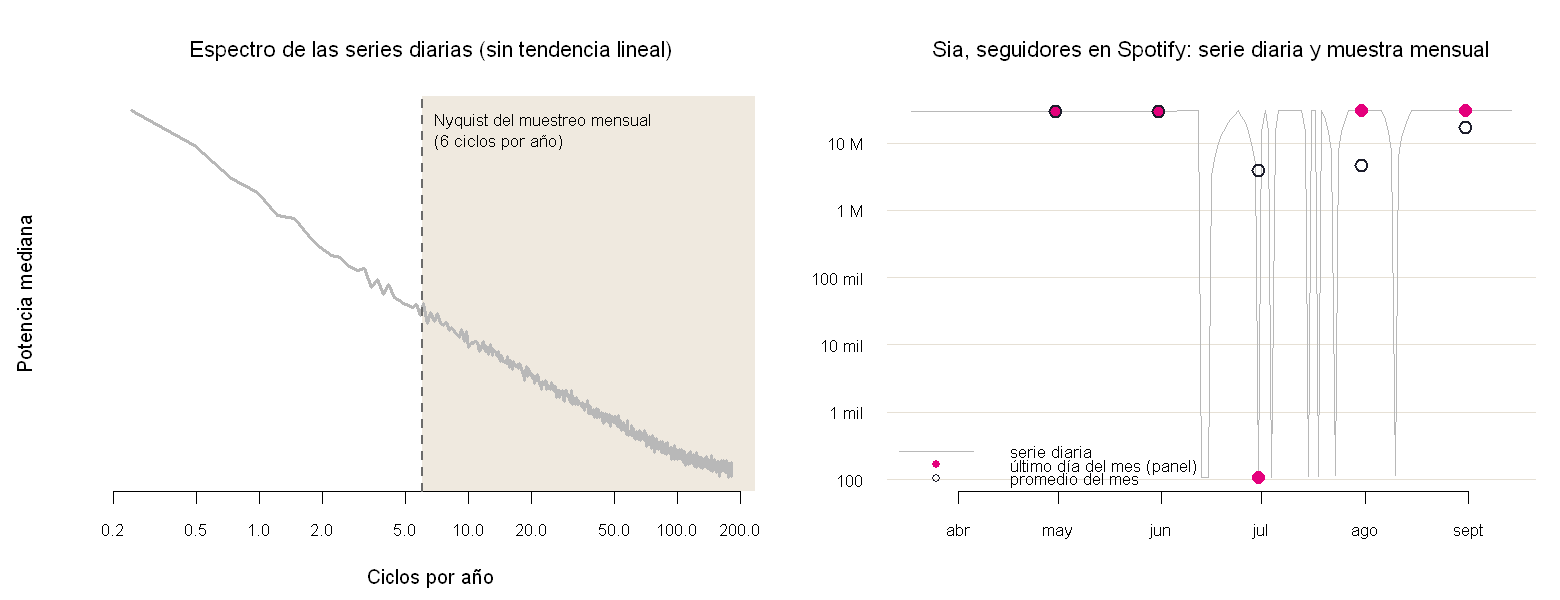

In [11]:
# ============================================================
# FIGURA 2: espectro diario y un alias por muestreo mensual
# ============================================================

espectro_diario_mediano <- espectro_diario[
  , .(potencia_mediana = median(potencia)), by = ciclos_por_anio
]

# Caso de alias: el mes cuyo ultimo dia mas se aparta del promedio
# del mes (un error de pocos dias que cae sobre la fecha muestreada)
caso_alias <- muestreo_mensual_comparado[which.max(abs(ultimo_dia - promedio_mes))]

serie_diaria_alias <- serie_diaria_uniforme[
  artist_id == caso_alias$artist_id & variable == caso_alias$variable &
    fecha %between% (caso_alias$month + c(-75, 105))
]

grafico_muestreo <- function() {

  par(mfrow = c(1, 2), bg = COLOR_FONDO, mar = c(4.5, 4.5, 4, 1), las = 1, cex.axis = 0.85)

  # a) espectro diario mediano y limite de Nyquist mensual
  plot(espectro_diario_mediano$ciclos_por_anio, espectro_diario_mediano$potencia_mediana,
       type = "n", log = "xy", bty = "n", xlab = "Ciclos por año", ylab = "Potencia mediana", yaxt = "n",
       main = "Espectro de las series diarias (sin tendencia lineal)", font.main = 1, cex.main = 1.1)
  rect(FRECUENCIA_NYQUIST_MENSUAL, 10^par("usr")[3], 10^par("usr")[2], 10^par("usr")[4], col = "#EFE9DF", border = NA)
  lines(espectro_diario_mediano$ciclos_por_anio, espectro_diario_mediano$potencia_mediana, col = COLOR_SERIE_BASE, lwd = 2.5)
  abline(v = FRECUENCIA_NYQUIST_MENSUAL, col = COLOR_REFERENCIA, lwd = 2, lty = 2)
  text(FRECUENCIA_NYQUIST_MENSUAL * 1.15, 10^par("usr")[4], adj = c(0, 1.5), cex = 0.85,
       "Nyquist del muestreo mensual\n(6 ciclos por año)")

  # b) serie diaria con un error de pocos dias y sus muestras mensuales
  meses_zoom <- muestreo_mensual_comparado[
    artist_id == caso_alias$artist_id & variable == caso_alias$variable &
      month %between% range(serie_diaria_alias$fecha)
  ]
  fechas_ultimo_dia <- seq(meses_zoom$month[1], by = "month", length.out = nrow(meses_zoom) + 1)[-1] - 1
  plot(serie_diaria_alias$fecha, expm1(serie_diaria_alias$log_valor), type = "n", log = "y",
       bty = "n", xlab = "", ylab = "", yaxt = "n",
       main = paste0(artistas_panel[artist_id == caso_alias$artist_id, artist_name], ", ",
                     en_minuscula_inicial(VARIABLES_PANEL[[caso_alias$variable]]), ": serie diaria y muestra mensual"),
       font.main = 1, cex.main = 1.1)
  marcas_y <- axTicks(2)
  axis(2, at = marcas_y, labels = etiqueta_eje_magnitud(marcas_y), col = NA)
  abline(h = marcas_y, col = COLOR_GRILLA)
  lines(serie_diaria_alias$fecha, expm1(serie_diaria_alias$log_valor), col = COLOR_SERIE_BASE, lwd = 1.5)
  points(fechas_ultimo_dia, expm1(meses_zoom$ultimo_dia), pch = 19, col = COLOR_ALERTA, cex = 1.4)
  points(fechas_ultimo_dia, expm1(meses_zoom$promedio_mes), pch = 21, col = COLOR_RESULTADO, lwd = 2, cex = 1.4)
  legend("bottomleft", bty = "n", cex = 0.85, lwd = c(1.5, NA, NA), pch = c(NA, 19, 1),
         col = c(COLOR_SERIE_BASE, COLOR_ALERTA, COLOR_RESULTADO),
         legend = c("serie diaria", "último día del mes (panel)", "promedio del mes"))
}

guardar_figura("prepro_02_muestreo_mensual.png", grafico_muestreo, ancho = 2600, alto = 1000)

En la serie típica, la energía por encima de 6 ciclos por año es del orden del 1 % y el último día del mes difiere del promedio mensual en menos de 1 %: las audiencias acumuladas cambian lento y el muestreo mensual las representa bien. Las excepciones son errores de la fuente que duran pocos días: si uno cae sobre el último día del mes, el muestreo lo convierte en un pico mensual aislado. Ese es el origen de los picos que se corrigen en el bloque siguiente.

**Muestreo en amplitud.** El muestreo también discretiza la amplitud: el paso Δx entre dos valores posibles. Los conteos de Chartmetric son enteros (Δx = 1 seguidor), salvo los suscriptores de YouTube, que la plataforma publica redondeados a tres cifras significativas: con 50 millones de suscriptores el escalón es de 100 mil. La celda siguiente mide cuántos valores vienen redondeados y compara el escalón relativo con el cambio mensual típico.

In [12]:
# ============================================================
# MUESTREO EN AMPLITUD: redondeo de los conteos en la fuente
# ============================================================

cifras_significativas <- function(x) {
  nchar(sub("0+$", "", format(round(x), scientific = FALSE, trim = TRUE)))
}

# Proporcion de valores (desde 1000) con tres cifras significativas
# o menos: en un conteo exacto es rara, en uno redondeado es la norma
panel_long[
  !is.na(valor_crudo) & valor_crudo >= 1e3,
  .(pct_valores_hasta_3_cifras = round(100 * mean(cifras_significativas(valor_crudo) <= 3), 1)),
  by = variable
]

# Escalon de redondeo relativo al valor (Delta x / x) frente al cambio
# mensual tipico de los suscriptores de YouTube, ambos en %
suscriptores_youtube <- panel_long[variable == "youtube_channel_subscribers" & !is.na(valor_crudo)]

cat(
  "Escalón de redondeo mediano:",
  round(100 * suscriptores_youtube[valor_crudo >= 1e3, median(10^(floor(log10(valor_crudo)) - 2) / valor_crudo)], 2), "%
",
  "Cambio mensual mediano:",
  round(100 * suscriptores_youtube[, .(cambio = abs(diff(log1p(valor_crudo)))), by = artist_id][, median(cambio, na.rm = TRUE)], 2), "%
"
)

# Ejemplo: primeros meses de Ed Sheeran
panel_long[.(ARTISTAS_FIGURA_PRESENTACION[1], "youtube_channel_subscribers"), head(valor_crudo, 6)]

variable,pct_valores_hasta_3_cifras
<chr>,<dbl>
instagram_followers,0.4
spotify_followers,0.1
spotify_playlist_count,0.7
youtube_channel_subscribers,60.9
youtube_playlist_count,10.6


Escalón de redondeo mediano: 0.31 %
 Cambio mensual mediano: 0.58 %


[1] 51400000 51700000 51900000 52000000 52200000 52300000

Seis de cada diez valores de suscriptores de YouTube vienen redondeados, contra menos del 1 % en las otras variables. El escalón de redondeo es del orden de la mitad del cambio mensual típico: en los canales que crecen lento la serie avanza en escalera, con meses sin cambio seguidos de un salto. No borra la forma de la trayectoria, y la media móvil de 3 meses (bloque 7) reparte esos escalones.

## 4. Picos aislados y faltantes

La limpieza y la imputación se hacen sobre `log1p` del valor; la sección 5 completa la transformación con el centrado por artista.

**Picos aislados.** En las variables de audiencia acumulada (seguidores y suscriptores), un mes que se duplica o cae a la mitad y vuelve al nivel anterior al mes siguiente no es un cambio de audiencia sino un error de la fuente. Esos meses se tratan como faltantes. Las cuentas de playlists sí suben y bajan de un mes a otro, por eso no se tocan.

**Cambios de nivel.** Una caída a menos de la mitad que no se revierte suele indicar un cambio de perfil o de canal en la fuente. Como no hay forma confiable de corregirla, esos artistas se excluyen del panel.

**Quiebres comunes.** Si en un mismo mes casi todos los artistas saltan en el mismo sentido, el cambio no es de los artistas sino de lo que mide la fuente. En esos meses se empalma la serie: el salto de cada artista se reemplaza por su cambio mensual típico y el tramo anterior se reescala, conservando el nivel más reciente. Es el tratamiento habitual de una serie que cambia de metodología.

**Faltantes.** Se imputan por interpolación lineal (`approx`) sobre `log1p` del valor, lo que equivale a suponer crecimiento a tasa constante dentro del hueco. Se prefiere la interpolación lineal a la spline porque la spline cúbica puede oscilar e incluso decrecer dentro de un hueco largo, algo que una audiencia acumulada no hace. Los meses previos al primer dato toman el primer valor observado (`rule = 2`): no se inventa una tendencia que no se observó. Cada celda imputada queda marcada.

In [13]:
# ============================================================
# LIMPIEZA DE PICOS AISLADOS E IMPUTACION DE FALTANTES
# ============================================================

panel_long[, log_valor := log1p(valor_crudo)]

panel_long[, pico_aislado := FALSE]

panel_long[
  variable %in% VARIABLES_STOCK_AUDIENCIA,
  pico_aislado := {
    salto_previo <- log_valor - shift(log_valor)
    salto_siguiente <- shift(log_valor, -1) - log_valor
    !is.na(salto_previo) & !is.na(salto_siguiente) &
      abs(salto_previo) > UMBRAL_SALTO_FUENTE &
      abs(salto_siguiente) > UMBRAL_SALTO_FUENTE &
      sign(salto_previo) != sign(salto_siguiente)
  },
  by = .(artist_id, variable)
]

panel_long[(pico_aislado), log_valor := NA_real_]

panel_long[, imputado := is.na(log_valor)]

panel_long[
  ,
  log_valor := approx(
    x = mes_indice[!imputado],
    y = log_valor[!imputado],
    xout = mes_indice,
    rule = 2
  )$y,
  by = .(artist_id, variable)
]

In [14]:
# ------------------------------------------------------------
# CONTROL: sin faltantes despues de imputar, picos y celdas
# imputadas por variable, y detalle de los picos corregidos
# ------------------------------------------------------------

stopifnot(!anyNA(panel_long$log_valor))

panel_long[
  ,
  .(picos_aislados = sum(pico_aislado),
    celdas_imputadas = sum(imputado),
    pct_imputado = round(100 * mean(imputado), 2)),
  by = variable
]

panel_long[
  (pico_aislado),
  .(artist_name, variable, month, valor_crudo, valor_corregido = round(expm1(log_valor)))
]

variable,picos_aislados,celdas_imputadas,pct_imputado
<chr>,<int>,<int>,<dbl>
instagram_followers,0,576,1.07
spotify_followers,7,38,0.07
spotify_playlist_count,0,2,0.00
youtube_channel_subscribers,2,201,0.37
youtube_playlist_count,0,485,0.90


artist_name,variable,month,valor_crudo,valor_corregido
<chr>,<chr>,<date>,<dbl>,<dbl>
Sia,spotify_followers,2025-06-01,109,30024594
Jasmine Thompson,spotify_followers,2025-07-01,2130,875284
Shreya Ghoshal,spotify_followers,2023-08-01,380,19362358
Ozuna,spotify_followers,2023-05-01,3313,36818608
Feid,spotify_followers,2023-02-01,203,3846795
Elodie,youtube_channel_subscribers,2024-10-01,61,352304
NAV,spotify_followers,2025-05-01,1421642,3549641
Lil Baby,spotify_followers,2023-05-01,8262,14198799
"Dream, Ivory",youtube_channel_subscribers,2023-01-01,7090,14797


In [15]:
# ============================================================
# EXCLUSION DE ARTISTAS CON CAMBIOS DE NIVEL DE LA FUENTE
# (caida mensual mayor al umbral que no se revierte; los picos
# aislados ya fueron imputados y no cuentan como caida)
# ============================================================

series_con_cambio_nivel <- panel_long[
  variable %in% VARIABLES_STOCK_AUDIENCIA,
  .(caida_maxima = min(diff(log_valor)), mes_caida = month[which.min(diff(log_valor)) + 1]),
  by = .(artist_id, artist_name, variable)
][caida_maxima < -UMBRAL_SALTO_FUENTE]

stopifnot(!any(ARTISTAS_FIGURA_PRESENTACION %in% series_con_cambio_nivel$artist_id))

panel_long <- panel_long[!series_con_cambio_nivel, on = "artist_id"]
artistas_panel <- artistas_panel[!series_con_cambio_nivel, on = "artist_id"]

cat("Artistas excluidos:", uniqueN(series_con_cambio_nivel$artist_id),
    "| artistas en el panel:", nrow(artistas_panel), "\n")

series_con_cambio_nivel[order(caida_maxima), .(artist_name, variable, mes_caida, caida_maxima = round(caida_maxima, 2))]

Artistas excluidos: 15 | artistas en el panel: 1083 


artist_name,variable,mes_caida,caida_maxima
<chr>,<chr>,<date>,<dbl>
Dave,spotify_followers,2025-06-01,-13.23
Russ,spotify_followers,2025-06-01,-9.02
Budi Doremi,youtube_channel_subscribers,2025-05-01,-7.79
Pendulum,youtube_channel_subscribers,2025-07-01,-4.82
Favé,youtube_channel_subscribers,2025-05-01,-3.63
Randy Nota Loca,youtube_channel_subscribers,2023-03-01,-2.06
The Wallflowers,youtube_channel_subscribers,2025-05-01,-2.03
ATL Jacob,spotify_followers,2022-05-01,-1.90
ICON,youtube_channel_subscribers,2023-07-01,-1.11


In [16]:
# ============================================================
# EMPALME EN QUIEBRES COMUNES DE LA FUENTE
# ============================================================

meses_quiebre_comun <- panel_long[
  ,
  .(month, cambio = log_valor - shift(log_valor)),
  by = .(artist_id, variable)
][
  !is.na(cambio),
  .(pct_suben = round(100 * mean(cambio > CAMBIO_MINIMO_QUIEBRE_COMUN), 1),
    pct_bajan = round(100 * mean(cambio < -CAMBIO_MINIMO_QUIEBRE_COMUN), 1)),
  by = .(variable, month)
][
  pmax(pct_suben, pct_bajan) >= 100 * PROPORCION_QUIEBRE_COMUN
]

panel_long[, empalme := FALSE]
panel_long[meses_quiebre_comun, empalme := TRUE, on = .(variable, month)]

# Cambio del mes de quiebre = mediana de los cambios del artista en
# los demas meses; se reconstruye la serie anclada en el ultimo mes
panel_long[
  variable %in% meses_quiebre_comun$variable,
  log_valor := {
    cambio <- c(0, diff(log_valor))
    cambio[empalme] <- median(cambio[-1][!empalme[-1]])
    serie_empalmada <- cumsum(cambio)
    serie_empalmada - serie_empalmada[.N] + log_valor[.N]
  },
  by = .(artist_id, variable)
]

meses_quiebre_comun

variable,month,pct_suben,pct_bajan
<chr>,<date>,<dbl>,<dbl>
youtube_playlist_count,2022-04-01,74.1,1.1
youtube_playlist_count,2022-09-01,89.0,1.8


In [17]:
# ------------------------------------------------------------
# CONTROL: mediana mensual del panel antes y despues del empalme
# en la variable afectada, alrededor de los meses de quiebre
# ------------------------------------------------------------

panel_long[
  variable %in% meses_quiebre_comun$variable & month <= max(meses_quiebre_comun$month) + 62,
  .(mediana_cruda = median(valor_crudo, na.rm = TRUE),
    mediana_empalmada = round(median(expm1(log_valor)), 1),
    empalme = any(empalme)),
  by = .(variable, month)
]

variable,month,mediana_cruda,mediana_empalmada,empalme
<chr>,<date>,<dbl>,<dbl>,<lgl>
youtube_playlist_count,2022-03-01,5,30.4,FALSE
youtube_playlist_count,2022-04-01,13,30.4,TRUE
youtube_playlist_count,2022-05-01,13,31.0,FALSE
youtube_playlist_count,2022-06-01,13,31.8,FALSE
youtube_playlist_count,2022-07-01,14,31.5,FALSE
youtube_playlist_count,2022-08-01,14,32.0,FALSE
youtube_playlist_count,2022-09-01,32,32.0,TRUE
youtube_playlist_count,2022-10-01,32,32.0,FALSE
youtube_playlist_count,2022-11-01,32,32.0,FALSE


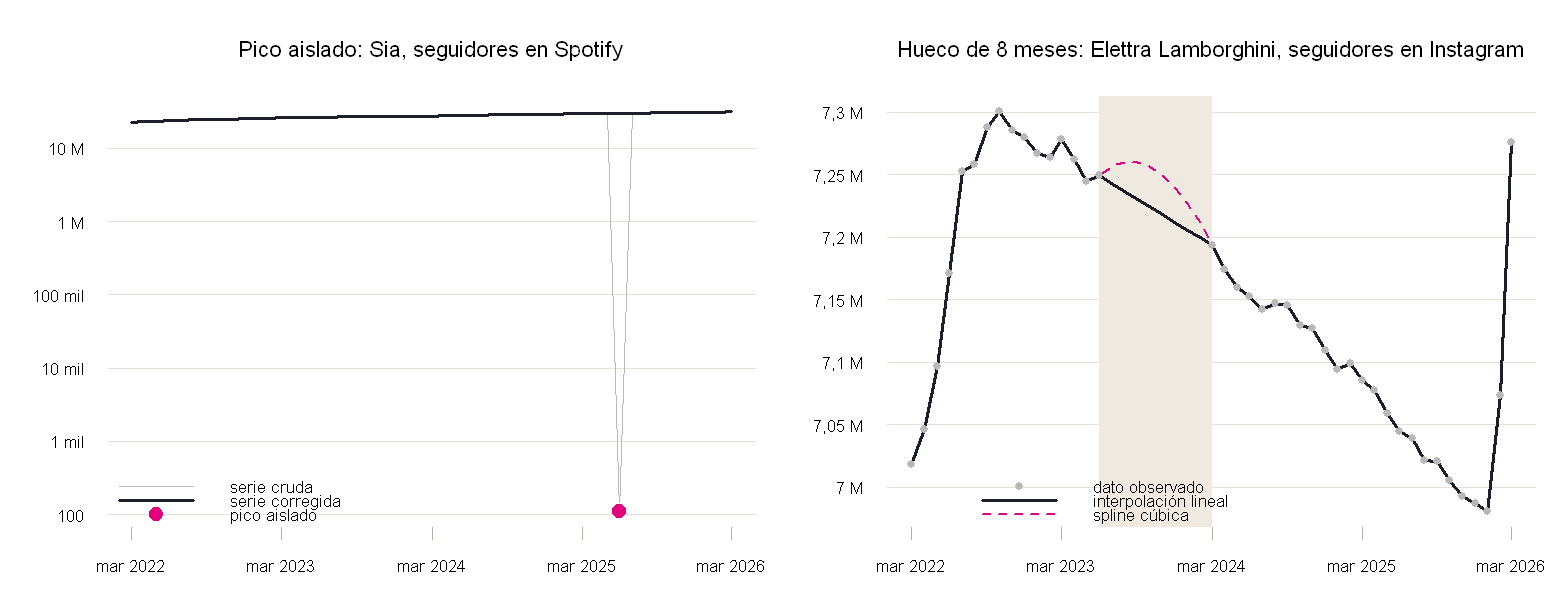

In [18]:
# ============================================================
# FIGURA 2: un pico aislado corregido y el hueco interno mas
# largo del panel, interpolacion lineal vs spline
# ============================================================

pico_figura <- panel_long[(pico_aislado)][
  which.max(abs(log1p(valor_crudo) - log_valor))
]

huecos_internos <- panel_long[
  ,
  {
    tramos <- rle(imputado & !pico_aislado)
    fin_tramo <- cumsum(tramos$lengths)
    inicio_tramo <- fin_tramo - tramos$lengths + 1
    .(largo = tramos$lengths[tramos$values], inicio = inicio_tramo[tramos$values])
  },
  by = .(artist_id, variable)
][inicio > 1]

hueco_figura <- huecos_internos[order(-largo)][1]

grafico_pico_y_hueco <- function() {

  par(mfrow = c(1, 2), bg = COLOR_FONDO, mar = c(3, 4.5, 4, 1), las = 1, cex.axis = 0.85)

  # a) pico aislado
  serie_pico <- panel_long[.(pico_figura$artist_id, pico_figura$variable)]
  abrir_lienzo(range(serie_pico$valor_crudo, na.rm = TRUE),
               paste0("Pico aislado: ", pico_figura$artist_name, ", ",
                      en_minuscula_inicial(VARIABLES_PANEL[[pico_figura$variable]])),
               escala_log = TRUE)
  lines(serie_pico$month, serie_pico$valor_crudo, col = COLOR_SERIE_BASE, lwd = 1.5)
  lines(serie_pico$month, expm1(serie_pico$log_valor), col = COLOR_RESULTADO, lwd = 2.5)
  points(pico_figura$month, pico_figura$valor_crudo, pch = 21, bg = COLOR_ALERTA, col = COLOR_FONDO, cex = 1.8)
  legend("bottomleft", c("serie cruda", "serie corregida", "pico aislado"), bty = "n", cex = 0.85,
         col = c(COLOR_SERIE_BASE, COLOR_RESULTADO, COLOR_ALERTA),
         lwd = c(1.5, 2.5, 0), lty = c(1, 1, 0), pch = c(NA, NA, 19), pt.cex = c(1, 1, 1.5))

  # b) hueco interno: interpolacion lineal (la usada) vs spline
  serie_hueco <- panel_long[.(hueco_figura$artist_id, hueco_figura$variable)]
  spline_hueco <- spline(serie_hueco[!(imputado), mes_indice], serie_hueco[!(imputado), log_valor],
                         xout = serie_hueco$mes_indice)$y
  abrir_lienzo(range(expm1(c(serie_hueco$log_valor, spline_hueco))),
               paste0("Hueco de ", hueco_figura$largo, " meses: ",
                      serie_hueco$artist_name[1], ", ",
                      en_minuscula_inicial(VARIABLES_PANEL[[hueco_figura$variable]])))
  meses_hueco <- serie_hueco$month[hueco_figura$inicio + c(-1, hueco_figura$largo)]
  rect(meses_hueco[1], par("usr")[3], meses_hueco[2], par("usr")[4], col = "#EFE9DF", border = NA)
  lines(serie_hueco$month, expm1(spline_hueco), col = COLOR_ALERTA, lwd = 2, lty = 2)
  lines(serie_hueco$month, expm1(serie_hueco$log_valor), col = COLOR_RESULTADO, lwd = 2.5)
  points(serie_hueco[!(imputado), month], serie_hueco[!(imputado), valor_crudo], pch = 19, col = COLOR_SERIE_BASE, cex = 0.9)
  legend("bottom", c("dato observado", "interpolación lineal", "spline cúbica"), bty = "n", cex = 0.85,
         col = c(COLOR_SERIE_BASE, COLOR_RESULTADO, COLOR_ALERTA),
         lwd = c(NA, 2.5, 2), lty = c(NA, 1, 2), pch = c(19, NA, NA))
}

guardar_figura("prepro_03_pico_y_hueco.png", grafico_pico_y_hueco, ancho = 2600, alto = 1000)

## 5. Transformación

Se aplica `log1p` y después se centra cada serie (un artista, una variable) restando su media.

**Por qué log1p.** Las audiencias crecen en proporción a su tamaño y los niveles van de decenas a cientos de millones. En escala log, duplicar la audiencia suma siempre 0,69, sea de 10 mil a 20 mil o de 10 a 20 millones: el crecimiento se vuelve comparable entre artistas y la variabilidad deja de depender del nivel. El +1 mantiene la transformación definida si una cuenta llega a cero.

**Por qué centrar por artista y variable.** Restar la media de cada serie quita el nivel y deja la forma de la trayectoria. Se hace por serie porque cada variable tiene su propia escala y cada artista su propio tamaño: sin centrar, el agrupamiento separaría a los artistas por popularidad, que ya es el criterio de estratificación de la muestra, y no por perfil. El nivel no se pierde: queda en `log_valor` para caracterizar después cada grupo.

Lectura: 0 es el nivel típico de la serie (su media geométrica); +0,69, el doble; -0,69, la mitad. A diferencia de un z-score, no reescala la amplitud: una trayectoria que creció 5 % y una que creció 500 % siguen siendo distintas. La transformación se cambia en `TRANSFORMACION` (alternativas: z-score sobre log1p, crecimiento acumulado desde el primer mes, serie sin transformar).

In [19]:
# ============================================================
# TRANSFORMACION DE LAS SERIES
# ============================================================

transformar_serie <- function(log_valor, metodo = TRANSFORMACION) {
  switch(
    metodo,
    log1p_centrado      = log_valor - mean(log_valor),
    log1p_estandarizado = if (sd(log_valor) > 0) (log_valor - mean(log_valor)) / sd(log_valor)
                          else log_valor - mean(log_valor),
    log1p_desde_inicio  = log_valor - log_valor[1],
    sin_transformar     = expm1(log_valor),
    stop("TRANSFORMACION no reconocida: ", metodo)
  )
}

panel_long[
  ,
  valor_transformado := transformar_serie(log_valor),
  by = .(artist_id, variable)
]

In [20]:
# ------------------------------------------------------------
# CONTROL: media de cada serie transformada (cero con el
# centrado) y amplitud de las trayectorias por variable
# (maximo menos minimo, en unidades log)
# ------------------------------------------------------------

amplitud_series <- panel_long[
  ,
  .(media = mean(valor_transformado), amplitud = diff(range(valor_transformado))),
  by = .(artist_id, variable)
]

cat("Rango de las medias por serie:", signif(range(amplitud_series$media), 3), "\n")

amplitud_series[, as.list(round(quantile(amplitud, c(0.1, 0.5, 0.9)), 2)), by = variable]

Rango de las medias por serie: -1.74e-15 1.74e-15 


variable,10%,50%,90%
<chr>,<dbl>,<dbl>,<dbl>
instagram_followers,0.08,0.38,1.39
spotify_followers,0.19,0.48,1.58
spotify_playlist_count,0.73,0.93,1.48
youtube_channel_subscribers,0.06,0.34,1.34
youtube_playlist_count,0.32,0.73,1.80


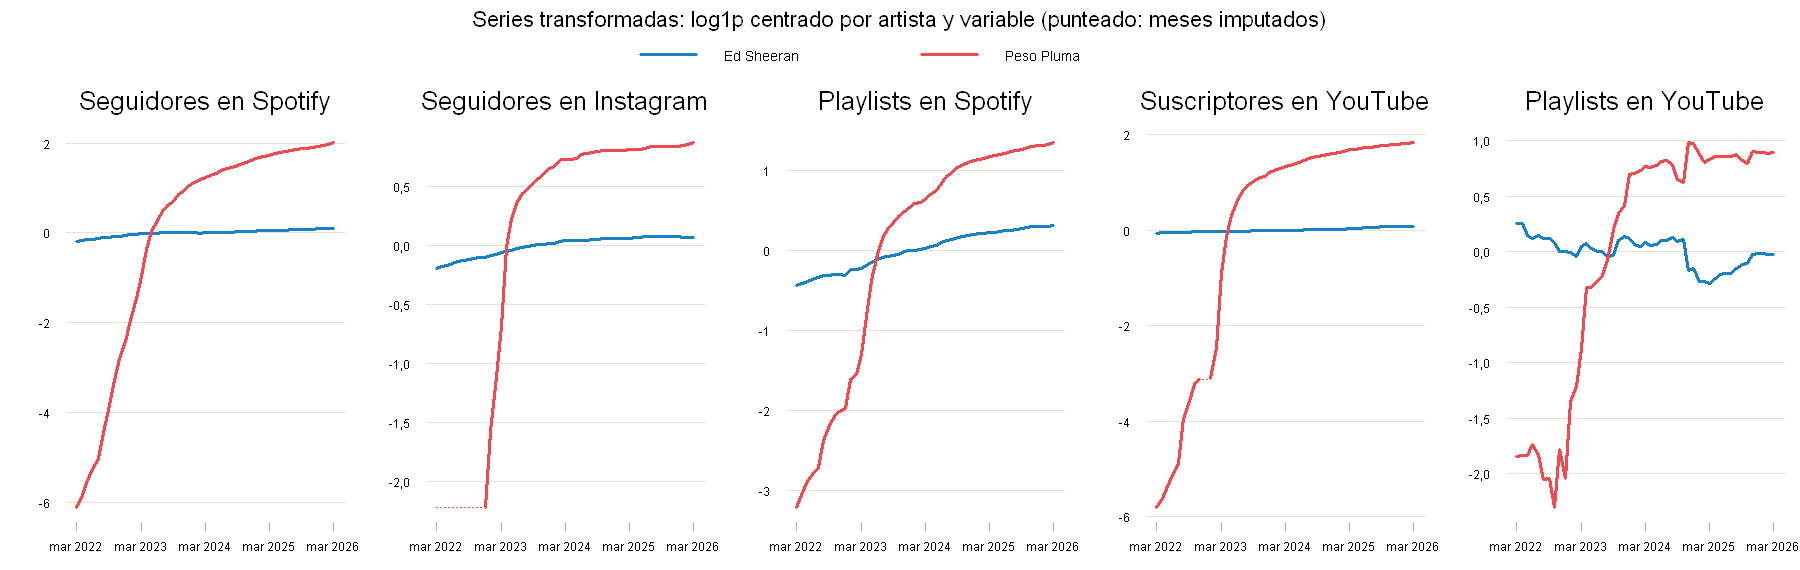

In [21]:
# ============================================================
# FIGURA 3: los mismos artistas despues de la transformacion
# ============================================================

guardar_figura(
  "prepro_04_series_transformadas.png",
  function() grafico_cinco_variables(
    "valor_transformado",
    "Series transformadas: log1p centrado por artista y variable (punteado: meses imputados)",
    escala_log = FALSE
  ),
  ancho = 3000, alto = 950
)

Mes: 2026-03-01 | artistas con dato: 1083 de 1083 


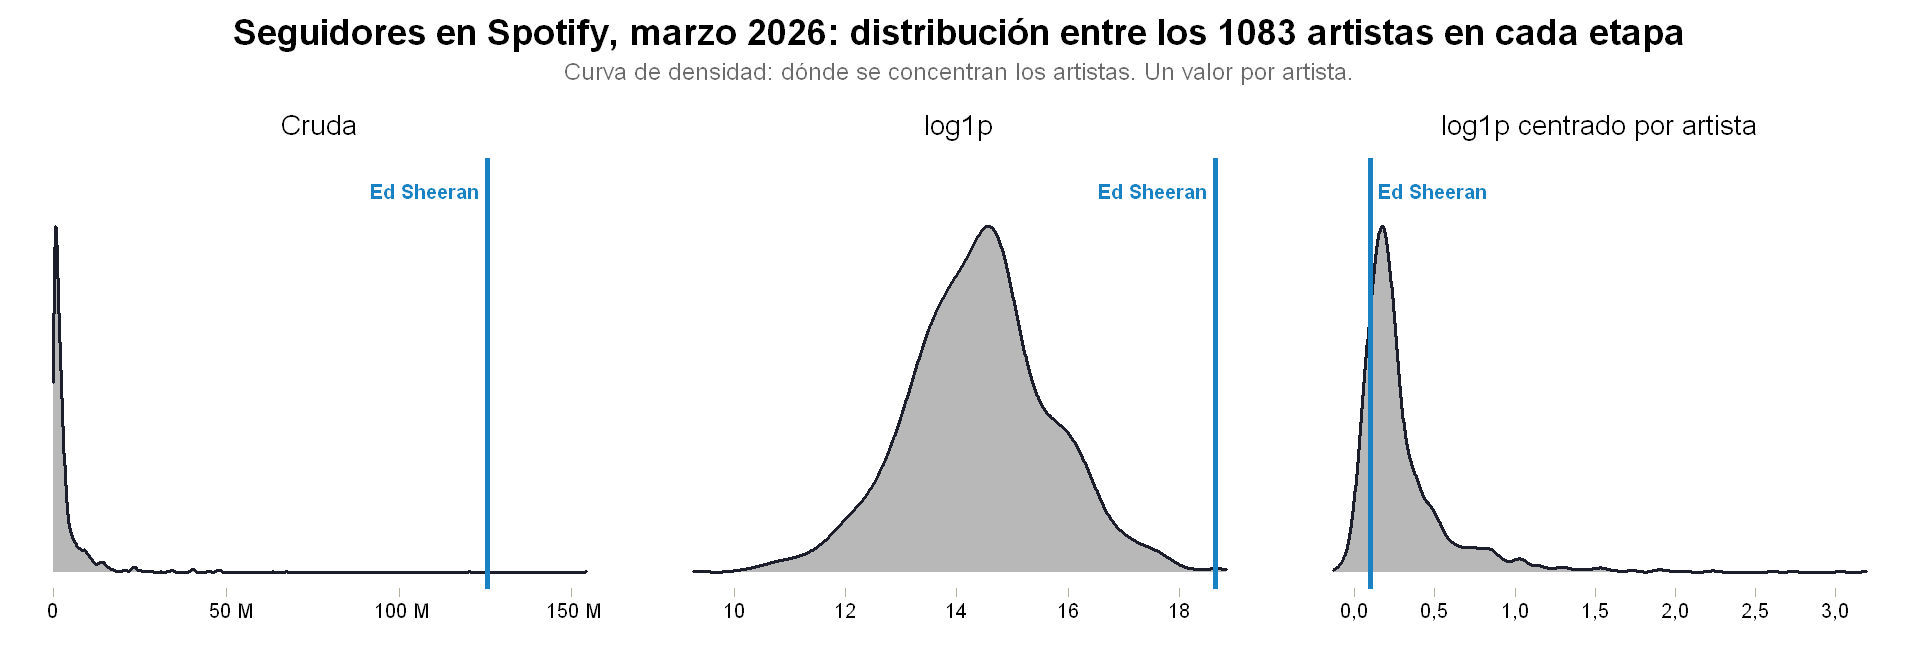

In [22]:
# ============================================================
# FIGURA 3b: distribucion de una variable entre artistas en un
# mes, en las tres etapas: cruda, log1p y log1p centrado por
# artista. Ed Sheeran marcado como referencia
# ============================================================

VARIABLE_DISTRIBUCION <- "spotify_followers"
ARTISTA_DISTRIBUCION <- ARTISTAS_FIGURA_PRESENTACION[1]
COLOR_ARTISTA_DISTRIBUCION <- PALETA_ARTISTAS[1]

# Mes con mayor cobertura de datos observados en la variable (el
# mas reciente si hay empate). Solo artistas del panel final.
cobertura_por_mes <- panel_long[
  variable == VARIABLE_DISTRIBUCION,
  .(observados = sum(!is.na(valor_crudo))),
  by = month
]
MES_DISTRIBUCION <- cobertura_por_mes[observados == max(observados), max(month)]

corte_distribucion <- panel_long[
  variable == VARIABLE_DISTRIBUCION & month == MES_DISTRIBUCION & !is.na(valor_crudo),
  .(artist_id, cruda = valor_crudo, log1p = log_valor, centrada = valor_transformado)
]

cat(
  "Mes:", format(MES_DISTRIBUCION), "| artistas con dato:", nrow(corte_distribucion),
  "de", uniqueN(panel_long$artist_id), "\n"
)

ETAPAS_DISTRIBUCION <- c(
  cruda = "Cruda",
  log1p = "log1p",
  centrada = "log1p centrado por artista"
)

TAMANIO_TITULO_DISTRIBUCION <- 1.8
TAMANIO_TITULO_PANEL_DISTRIBUCION <- 2.1
TAMANIO_TEXTO_DISTRIBUCION <- 1.5

grafico_densidad_etapas <- function() {

  # con 3 paneles en fila R reduce los textos a 2/3: los tamanios
  # de arriba lo compensan
  par(mfrow = c(1, length(ETAPAS_DISTRIBUCION)), bg = COLOR_FONDO, mar = c(4.5, 2, 4, 2),
      oma = c(0, 0, 6, 0), las = 1, cex.axis = TAMANIO_TEXTO_DISTRIBUCION)

  for (etapa in names(ETAPAS_DISTRIBUCION)) {

    valores <- corte_distribucion[[etapa]]
    densidad <- density(valores, n = 1024, from = if (etapa == "cruda") 0 else min(valores),
                        to = max(valores))
    valor_artista <- corte_distribucion[artist_id == ARTISTA_DISTRIBUCION, get(etapa)]

    plot(densidad$x, densidad$y, type = "n", bty = "n", xlab = "", ylab = "", yaxt = "n", xaxt = "n",
         ylim = c(0, max(densidad$y) * 1.15))
    title(ETAPAS_DISTRIBUCION[[etapa]], font.main = 1, cex.main = TAMANIO_TITULO_PANEL_DISTRIBUCION, line = 1.5)

    marcas_x <- axTicks(1)
    axis(1, at = marcas_x, col = NA, col.ticks = "#B8B0A2",
         labels = if (etapa == "cruda") etiqueta_eje_magnitud(marcas_x) else format(marcas_x, decimal.mark = ","))

    polygon(c(densidad$x, rev(densidad$x)), c(densidad$y, rep(0, length(densidad$y))),
            col = COLOR_SERIE_BASE, border = NA)
    lines(densidad$x, densidad$y, col = COLOR_RESULTADO, lwd = 2.5)

    abline(v = valor_artista, col = COLOR_ARTISTA_DISTRIBUCION, lwd = 4)
    text(valor_artista, max(densidad$y) * 1.1, artistas_panel[artist_id == ARTISTA_DISTRIBUCION, artist_name],
         pos = if (valor_artista > mean(range(densidad$x))) 2 else 4,
         col = COLOR_ARTISTA_DISTRIBUCION, cex = TAMANIO_TEXTO_DISTRIBUCION, font = 2)
  }

  mtext(paste0(VARIABLES_PANEL[[VARIABLE_DISTRIBUCION]], ", ", format(MES_DISTRIBUCION, "%B %Y"),
               ": distribución entre los ", nrow(corte_distribucion), " artistas en cada etapa"),
        side = 3, outer = TRUE, line = 3, font = 2, cex = TAMANIO_TITULO_DISTRIBUCION)
  mtext("Curva de densidad: dónde se concentran los artistas. Un valor por artista.",
        side = 3, outer = TRUE, line = 0.8, cex = 1.2, col = COLOR_REFERENCIA)
}

guardar_figura("prepro_04b_distribucion_etapas.png", grafico_densidad_etapas, ancho = 3200, alto = 1100)


En un mismo mes, la misma variable cambia de forma en cada etapa. Cruda, casi todos los artistas se amontonan contra el cero y unos pocos masivos estiran una cola larga hacia la derecha. Con log1p la distribución se vuelve una campana aproximadamente simétrica: las diferencias entre artistas pasan a medirse en proporciones. El centrado resta a cada artista su propio promedio en el tiempo, de modo que el valor de un mes ya no dice cuán grande es el artista sino cuánto se aparta de su propia trayectoria. En el último mes del panel casi todos los artistas quedan por encima de cero, porque crecieron, y la cola derecha ya no la forman los artistas masivos sino los de crecimiento más fuerte. Ed Sheeran, que en las dos primeras etapas está en el extremo de la distribución, queda junto al cero: es un artista enorme pero estable.


## 6. Estacionaridad

Una serie es estacionaria si su media y su varianza no cambian en el tiempo. Se aplican a cada serie transformada y a su primera diferencia las dos pruebas vistas en clase: Dickey-Fuller aumentada (H0: raíz unitaria, no estacionaria) y KPSS (H0: estacionaria). La decisión combina ambas: estacionaria si ADF rechaza y KPSS no, no estacionaria en el caso inverso, indefinida en los otros dos.

In [23]:
# ============================================================
# PRUEBAS ADF Y KPSS POR SERIE: transformada y primera diferencia
# ============================================================

decidir_estacionaridad <- function(serie) {
  p_valores <- tryCatch(
    suppressWarnings(c(adf = adf.test(serie)$p.value, kpss = kpss.test(serie)$p.value)),
    error = function(e) c(adf = NA, kpss = NA)
  )
  fcase(
    p_valores[["adf"]] < 0.05 & p_valores[["kpss"]] >= 0.05, "estacionaria",
    p_valores[["adf"]] >= 0.05 & p_valores[["kpss"]] < 0.05, "no estacionaria",
    default = "indefinida"
  )
}

estacionaridad_series <- panel_long[
  ,
  .(transformada = decidir_estacionaridad(valor_transformado),
    primera_diferencia = decidir_estacionaridad(diff(valor_transformado))),
  by = .(artist_id, variable)
]

resumen_estacionaridad <- melt(
  estacionaridad_series,
  id.vars = c("artist_id", "variable"),
  variable.name = "version",
  value.name = "decision"
)[
  , .N, by = .(version, variable, decision)
][
  , pct := round(100 * N / sum(N), 1), by = .(version, variable)
]

dcast(resumen_estacionaridad, version + variable ~ decision, value.var = "pct", fill = 0)

version,variable,estacionaria,indefinida,no estacionaria
<fct>,<chr>,<dbl>,<dbl>,<dbl>
transformada,instagram_followers,1.0,9.0,90.0
transformada,spotify_followers,0.0,5.6,94.4
transformada,spotify_playlist_count,0.0,1.3,98.7
transformada,youtube_channel_subscribers,0.4,13.3,86.3
transformada,youtube_playlist_count,5.4,36.2,58.4
primera_diferencia,instagram_followers,13.4,59.0,27.6
primera_diferencia,spotify_followers,6.7,45.6,47.6
primera_diferencia,spotify_playlist_count,4.0,83.0,13.0
primera_diferencia,youtube_channel_subscribers,13.0,49.7,37.3


Casi todas las series de audiencia son no estacionarias, como se espera de stocks que crecen. La primera diferencia (la tasa de crecimiento mensual) reduce esa proporción pero no la elimina: en muchos artistas la propia tasa de crecimiento cambia en el tiempo, se acelera o se frena. Esa no estacionaridad es lo que distingue una trayectoria de otra, y por eso el análisis compara formas en lugar de ajustar modelos de pronóstico, que la requieren. Las playlists de YouTube son la variable menos marcada: una parte importante de las series oscila alrededor de un nivel en lugar de crecer.

La transformación se mantiene en nivel (log centrado) y no en diferencias: la diferencia es un pasa-altos que amplifica el ruido mes a mes y borra la forma acumulada. El crecimiento mensual se calcula aparte, sobre la serie suavizada (bloque 9).

## 7. Suavizado por media móvil

Media móvil centrada (un filtro FIR pasa-bajos) en dos escalas:

- **3 meses**, para quitar el ruido mes a mes sin borrar los saltos.
- **2×12 meses**, como tendencia anual: 13 meses con los dos extremos a mitad de peso. Una ventana de 12 no se puede centrar, y una de 13 con pesos iguales contaría dos veces el mismo mes calendario; el 2×12 resuelve ambas cosas y es el filtro que usa `decompose()` para series mensuales.

Restar una de otra separa la tendencia de la fluctuación intermedia, la descomposición por diferencia de medias móviles vista en clase. No se usa `filter(..., circular = TRUE)`: una trayectoria no es periódica y el filtro circular mezclaría marzo de 2026 con marzo de 2022. En los bordes, donde la ventana no entra completa, se promedia una ventana simétrica más corta.

In [24]:
# ============================================================
# MEDIA MOVIL CENTRADA SOBRE TODO EL PANEL
# ============================================================

stopifnot(
  VENTANAS_MEDIA_MOVIL[["suavizado"]] %% 2 == 1,
  VENTANAS_MEDIA_MOVIL[["tendencia"]] %% 2 == 0
)

# Media movil simple centrada, ventana impar
media_movil_centrada <- function(x, ventana) {
  largo_serie <- length(x)
  posiciones <- seq_len(largo_serie)
  semiancho <- pmin((ventana - 1) %/% 2, posiciones - 1, largo_serie - posiciones)
  sumas_acumuladas <- c(0, cumsum(x))
  (sumas_acumuladas[posiciones + semiancho + 1] - sumas_acumuladas[posiciones - semiancho]) /
    (2 * semiancho + 1)
}

# Media movil 2xn centrada (n par): n + 1 coeficientes, extremos a
# mitad de peso. En los bordes, media simple simetrica mas corta
media_movil_2xn <- function(x, n) {
  pesos <- c(0.5, rep(1, n - 1), 0.5) / n
  tendencia <- as.numeric(stats::filter(x, pesos, sides = 2))
  bordes <- is.na(tendencia)
  tendencia[bordes] <- media_movil_centrada(x, n + 1)[bordes]
  tendencia
}

panel_long[
  ,
  `:=`(
    valor_suavizado = media_movil_centrada(valor_transformado, VENTANAS_MEDIA_MOVIL[["suavizado"]]),
    tendencia = media_movil_2xn(valor_transformado, VENTANAS_MEDIA_MOVIL[["tendencia"]])
  ),
  by = .(artist_id, variable)
]

In [25]:
# ------------------------------------------------------------
# CONTROL: lejos de los bordes, el suavizado coincide con filter()
# de la clase (no circular) y la tendencia con la de decompose()
# ------------------------------------------------------------

serie_control <- panel_long[.(ARTISTAS_FIGURA_PRESENTACION[1], VARIABLE_ILUSTRATIVA)]

suavizado_clase <- as.numeric(stats::filter(
  serie_control$valor_transformado,
  rep(1 / VENTANAS_MEDIA_MOVIL[["suavizado"]], VENTANAS_MEDIA_MOVIL[["suavizado"]]),
  sides = 2
))

tendencia_decompose <- as.numeric(decompose(
  ts(serie_control$valor_transformado, frequency = VENTANAS_MEDIA_MOVIL[["tendencia"]])
)$trend)

cat(
  "Suavizado igual a filter() en el interior:",
  isTRUE(all.equal(suavizado_clase[!is.na(suavizado_clase)],
                   serie_control$valor_suavizado[!is.na(suavizado_clase)])), "\n",
  "Tendencia igual a decompose() en el interior:",
  isTRUE(all.equal(tendencia_decompose[!is.na(tendencia_decompose)],
                   serie_control$tendencia[!is.na(tendencia_decompose)])), "\n"
)

Suavizado igual a filter() en el interior: TRUE 
 Tendencia igual a decompose() en el interior: TRUE 


Para ver el filtro sobre trayectorias distintas se toma un artista por tercil de `cm_artist_rank`, sin meses imputados en ninguna variable. Como se trata de productos de consumo masivo, se eligen nombres de reconocimiento público: hacen legible el ejemplo sin cambiar el método.

In [26]:
# ============================================================
# ARTISTAS ILUSTRATIVOS: tercil de rank y control de cobertura
# ============================================================

# Terciles por posicion y no por valor de rank, para no depender
# de cortes que caigan en valores repetidos
artistas_panel[
  ,
  tercil_rank := cut(
    frank(cm_artist_rank, ties.method = "first"),
    breaks = 3,
    labels = c("rank_alto", "rank_medio", "rank_bajo")
  )
]

ids_ilustrativos <- unname(ARTISTAS_ILUSTRATIVOS)

# Mismo orden que ARTISTAS_ILUSTRATIVOS (alto, medio, bajo)
artistas_ilustrativos <- artistas_panel[match(ids_ilustrativos, artist_id)]

artistas_ilustrativos[
  panel_long[artist_id %in% ids_ilustrativos, .(meses_imputados = sum(imputado)), by = artist_id],
  meses_imputados := i.meses_imputados,
  on = "artist_id"
]

stopifnot(
  "Algun artista ilustrativo no esta en el panel" = !anyNA(artistas_ilustrativos$artist_name),
  "Algun artista ilustrativo no cae en su tercil" =
    all(as.character(artistas_ilustrativos$tercil_rank) == names(ARTISTAS_ILUSTRATIVOS)),
  "Algun artista ilustrativo tiene meses imputados" = all(artistas_ilustrativos$meses_imputados == 0)
)

artistas_ilustrativos[, .(tercil_rank, artist_id, artist_name, cm_artist_rank)]

tercil_rank,artist_id,artist_name,cm_artist_rank
<fct>,<int>,<chr>,<int>
rank_alto,206907,TINI,420
rank_medio,276,Megadeth,2405
rank_bajo,2456,Abel Pintos,4545


In [27]:
# ============================================================
# PANEL 3 x 5 (no se genera): serie transformada, suavizado y
# tendencia para los tres artistas ilustrativos y las cinco
# variables. Se conserva para uso posterior
# ============================================================

grafico_suavizado <- function() {

  par(mfrow = c(length(ids_ilustrativos), length(VARIABLES_PANEL)), bg = COLOR_FONDO,
      mar = c(2.5, 3.8, 2.2, 0.8), oma = c(0, 3, 5, 0), las = 1, cex.axis = 0.8)

  for (i in seq_along(ids_ilustrativos)) {
    for (variable_figura in names(VARIABLES_PANEL)) {
      serie_artista <- panel_long[.(ids_ilustrativos[i], variable_figura)]
      abrir_lienzo(range(serie_artista$valor_transformado),
                   if (i == 1) VARIABLES_PANEL[[variable_figura]] else "")
      lines(serie_artista$month, serie_artista$valor_transformado, col = COLOR_SERIE_BASE, lwd = 1.5)
      lines(serie_artista$month, serie_artista$valor_suavizado, col = COLOR_MEDIA_MOVIL, lwd = 2)
      lines(serie_artista$month, serie_artista$tendencia, col = COLOR_TENDENCIA, lwd = 2)
    }
    mtext(paste0(artistas_ilustrativos$artist_name[i], " (rank ", artistas_ilustrativos$cm_artist_rank[i], ")"),
          side = 2, outer = TRUE, line = 1, las = 0, cex = 0.95,
          at = 1 - (i - 0.5) / length(ids_ilustrativos))
  }

  mtext("Suavizado por media móvil centrada",
        side = 3, outer = TRUE, line = 3, cex = 1.1)

  par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
  plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
  legend("top", horiz = TRUE, bty = "n", inset = c(0, 0.045), cex = 0.95, lwd = c(1.5, 2, 2),
         col = c(COLOR_SERIE_BASE, COLOR_MEDIA_MOVIL, COLOR_TENDENCIA),
         legend = c("transformada",
                    paste0("media móvil ", VENTANAS_MEDIA_MOVIL[["suavizado"]], " meses"),
                    paste0("tendencia (media móvil 2×", VENTANAS_MEDIA_MOVIL[["tendencia"]], ")")))
}

# guardar_figura("prepro_05_suavizado_media_movil_panel.png", grafico_suavizado, ancho = 3000, alto = 1900)

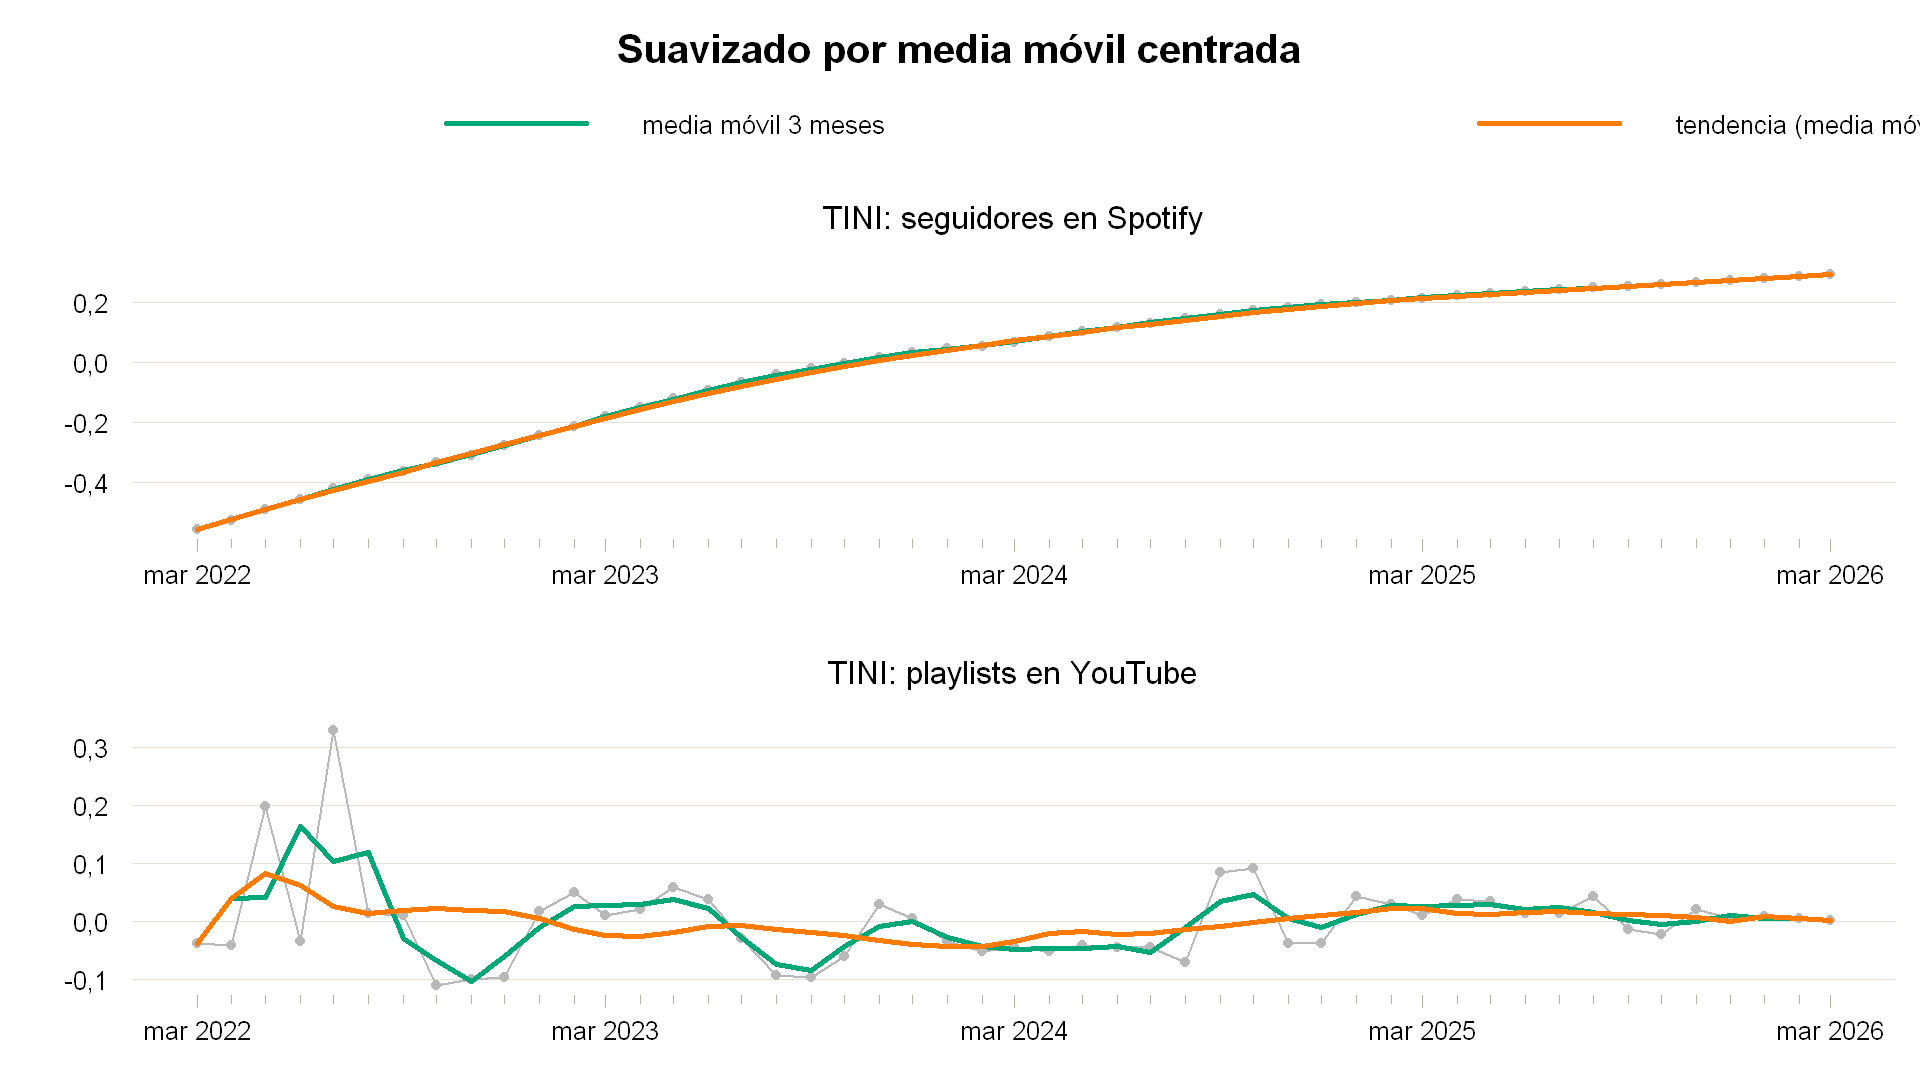

In [28]:
# ============================================================
# FIGURA 5: serie transformada, suavizado y tendencia de un
# artista ilustrativo, una variable lenta y una ruidosa
# ============================================================

ARTISTA_FIGURA_SUAVIZADO <- ARTISTAS_ILUSTRATIVOS[["rank_alto"]]
VARIABLES_FIGURA_SUAVIZADO <- c("spotify_followers", "youtube_playlist_count")

# Tamanios de texto: titulo general > titulo de cada panel > ejes y leyenda
TAMANIO_TITULO_FIGURA_5 <- 2
TAMANIO_TITULO_PANEL_FIGURA_5 <- 1.6
TAMANIO_TEXTO_FIGURA_5 <- 1.3

grafico_suavizado_artista <- function(
  artista = ARTISTA_FIGURA_SUAVIZADO,
  colores = c(transformada = COLOR_SERIE_BASE, media_movil = COLOR_MEDIA_MOVIL, tendencia = COLOR_TENDENCIA)
) {

  par(mfrow = c(length(VARIABLES_FIGURA_SUAVIZADO), 1), bg = COLOR_FONDO,
      mar = c(3.5, 5.5, 4, 1), oma = c(0, 0, 7, 0), las = 1, cex.axis = TAMANIO_TEXTO_FIGURA_5)

  for (variable_figura in VARIABLES_FIGURA_SUAVIZADO) {
    serie_artista <- panel_long[.(artista, variable_figura)]
    abrir_lienzo(range(serie_artista$valor_transformado), "")
    title(paste0(serie_artista$artist_name[1], ": ", en_minuscula_inicial(VARIABLES_PANEL[[variable_figura]])),
          font.main = 1, cex.main = TAMANIO_TITULO_PANEL_FIGURA_5, line = 1.5)
    # una marca y un punto por mes para que se vea la granularidad mensual
    axis(1, at = MESES_PANEL, labels = FALSE, col = NA, col.ticks = "#B8B0A2", tcl = -0.3)
    lines(serie_artista$month, serie_artista$valor_transformado, col = colores[["transformada"]], lwd = 2)
    points(serie_artista$month, serie_artista$valor_transformado, pch = 19, col = colores[["transformada"]], cex = 1.1)
    lines(serie_artista$month, serie_artista$valor_suavizado, col = colores[["media_movil"]], lwd = 4)
    lines(serie_artista$month, serie_artista$tendencia, col = colores[["tendencia"]], lwd = 4)
  }

  mtext("Suavizado por media móvil centrada",
        side = 3, outer = TRUE, line = 4.2, font = 2, cex = TAMANIO_TITULO_FIGURA_5)

  par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
  plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
  legend("top", horiz = TRUE, bty = "n", inset = c(0, 0.075), cex = TAMANIO_TEXTO_FIGURA_5,
         lwd = c(2, 4, 4), pch = c(19, NA, NA), pt.cex = 1.1, seg.len = 2.5,
         col = colores[c("transformada", "media_movil", "tendencia")],
         legend = c("transformada",
                    paste0("media móvil ", VENTANAS_MEDIA_MOVIL[["suavizado"]], " meses"),
                    paste0("tendencia (media móvil 2×", VENTANAS_MEDIA_MOVIL[["tendencia"]], ")")))
}

guardar_figura("prepro_05_suavizado_media_movil.png", grafico_suavizado_artista, ancho = 3200, alto = 1800)


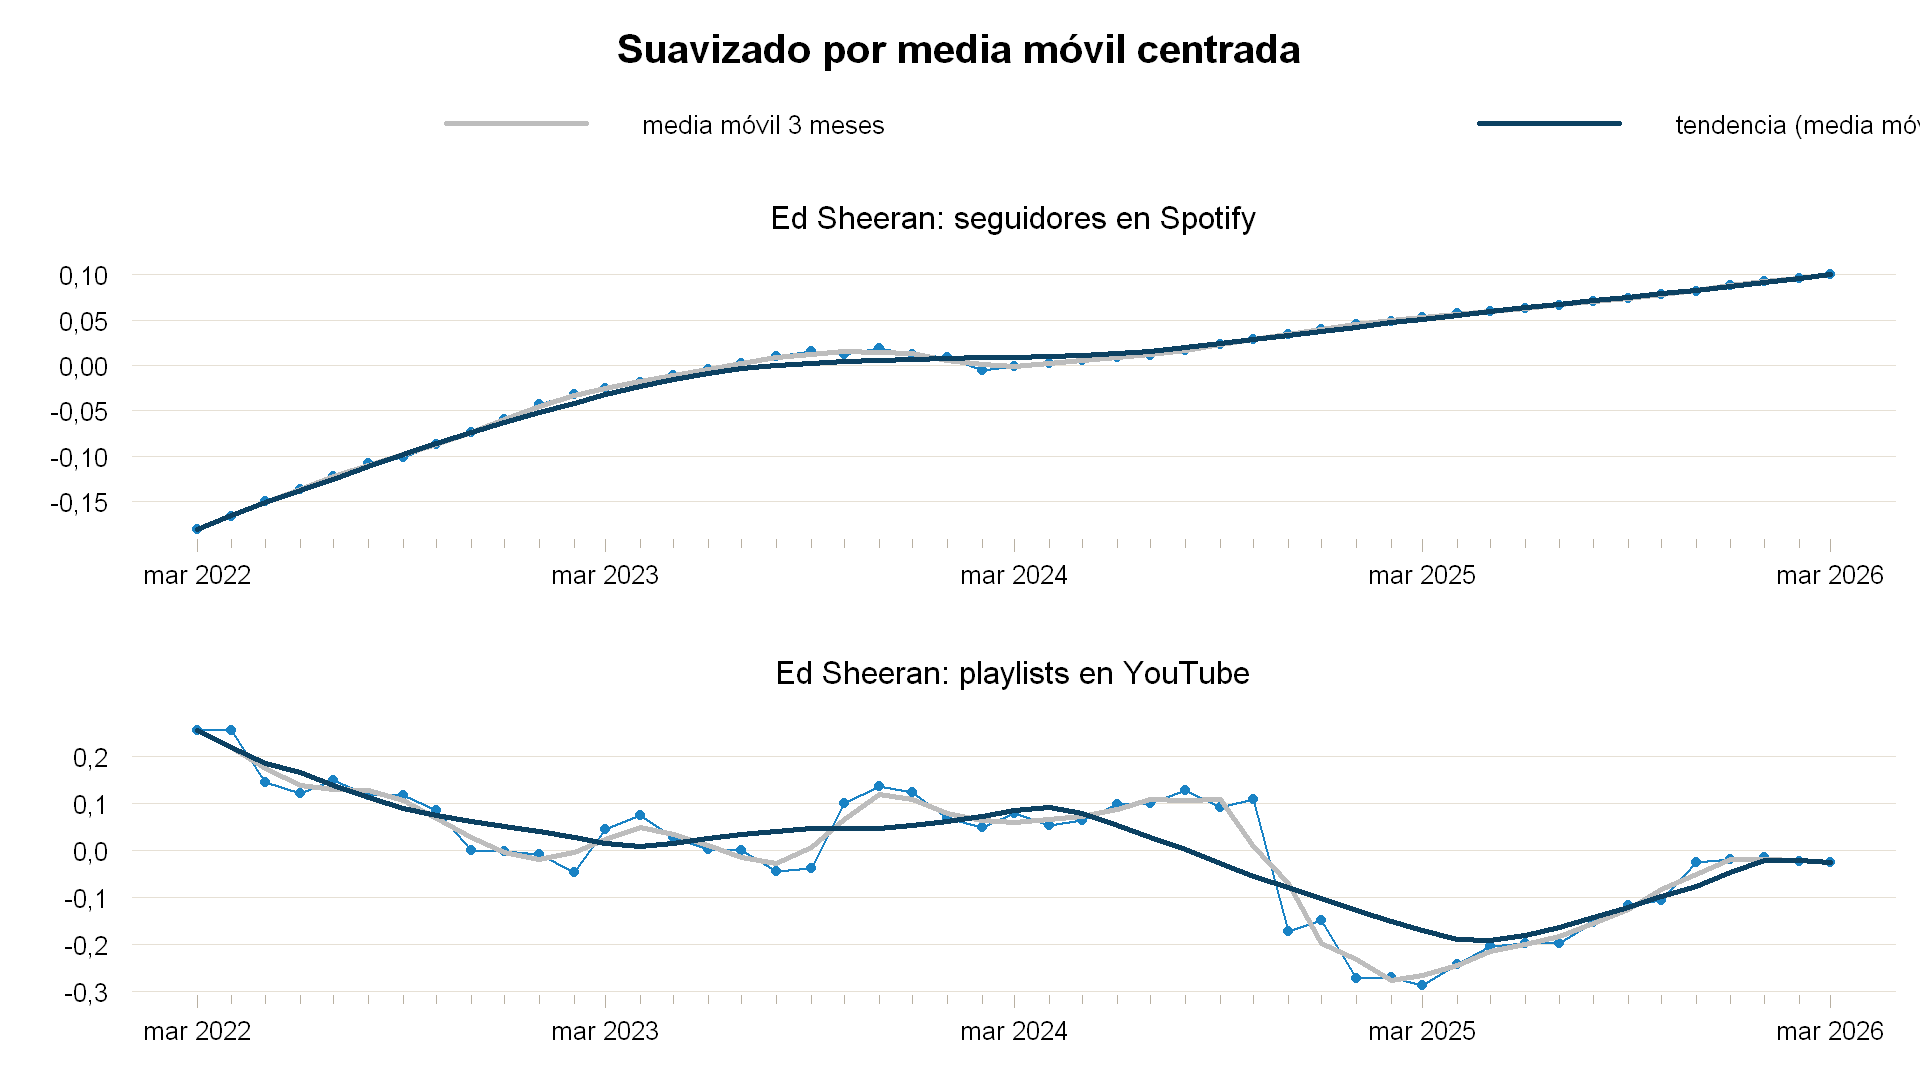

In [29]:
# ============================================================
# FIGURA 5, VERSION EN TONOS DEL ARTISTA: la figura 5 para el
# primer artista de la figura de presentacion, con tres tonos de
# su color (claro, propio y oscuro) en lugar de la codificacion
# general. Se guarda con el nombre del artista como sufijo.
# ============================================================

ARTISTA_VERSION_TONOS <- ARTISTAS_FIGURA_PRESENTACION[1]

COLOR_ARTISTA_VERSION_TONOS <- PALETA_ARTISTAS[match(ARTISTA_VERSION_TONOS, ARTISTAS_FIGURA_PRESENTACION)]

SUFIJO_VERSION_TONOS <- gsub(
  "[^a-z0-9]+", "_",
  tolower(artistas_panel[artist_id == ARTISTA_VERSION_TONOS, artist_name])
)

# Tres tonos de un mismo color: mezcla con blanco, el color
# original y mezcla con negro
tonos_de_color <- function(color) {
  escala <- colorRampPalette(c("#FFFFFF", color, "#000000"))(9)
  c(claro = escala[3], propio = escala[5], oscuro = escala[7])
}

TONOS_VERSION_ARTISTA <- tonos_de_color(COLOR_ARTISTA_VERSION_TONOS)

# Serie transformada en el color propio del artista, el mismo de
# la figura 4; media movil de 3 meses en gris claro, que contrasta
# con ese color y con el tono oscuro de la tendencia
COLOR_MEDIA_MOVIL_VERSION_TONOS <- "#BDBDBD"

guardar_figura(
  paste0("prepro_05_suavizado_media_movil_", SUFIJO_VERSION_TONOS, ".png"),
  function() grafico_suavizado_artista(
    artista = ARTISTA_VERSION_TONOS,
    colores = c(transformada = TONOS_VERSION_ARTISTA[["propio"]],
                media_movil = COLOR_MEDIA_MOVIL_VERSION_TONOS,
                tendencia = TONOS_VERSION_ARTISTA[["oscuro"]])
  ),
  ancho = 3200, alto = 1800
)


El efecto del filtro depende de la variable. En las audiencias acumuladas (seguidores y suscriptores) la serie ya es suave y las tres curvas casi se superponen. En las cuentas de playlists, sobre todo en YouTube, la media móvil de 3 meses quita las oscilaciones de un mes y deja ver el nivel. La tendencia 2×12 muestra el costo de una ventana ancha: en Abel Pintos borra casi por completo la caída de seguidores en Spotify de fines de 2023, un cambio real que la media de 3 meses conserva. Por eso el insumo del clustering es la serie suavizada a 3 meses y no la tendencia.

## 8. Dominio de la frecuencia

La FFT descompone cada serie en oscilaciones de distinta frecuencia. El armónico k es una oscilación que completa k ciclos en los 49 meses: k = 1 dura toda la ventana (0,24 ciclos por año) y k = 24 dura dos meses (6 ciclos por año, el límite de Nyquist del muestreo mensual). La altura de cada barra es la amplitud de esa oscilación, en las unidades log de la serie transformada.

Antes de la FFT se resta la recta de tendencia de cada serie. La FFT supone que la serie se repite: en una serie creciente, el salto entre el último mes y el primero repartiría amplitud artificial en todas las frecuencias.

In [30]:
# ============================================================
# ESPECTRO DE AMPLITUD POR SERIE
# ============================================================

N_ARMONICOS <- N_MESES_PANEL %/% 2
CICLOS_POR_ANIO_ARMONICOS <- seq_len(N_ARMONICOS) * 12 / N_MESES_PANEL

# Amplitud de cada armonico k = 1..N/2 de la serie sin su recta de
# tendencia. 2 * Mod / N es la amplitud de la oscilacion (la FFT
# reparte cada oscilacion entre k y su espejo N - k)
espectro_amplitud <- function(x) {
  residuo <- residuals(lm(x ~ seq_along(x)))
  2 * Mod(fft(residuo))[2:(N_ARMONICOS + 1)] / length(x)
}

espectro_panel <- panel_long[
  ,
  .(armonico = seq_len(N_ARMONICOS),
    ciclos_por_anio = CICLOS_POR_ANIO_ARMONICOS,
    amplitud_transformada = espectro_amplitud(valor_transformado),
    amplitud_suavizada = espectro_amplitud(valor_suavizado)),
  by = .(artist_id, variable)
]

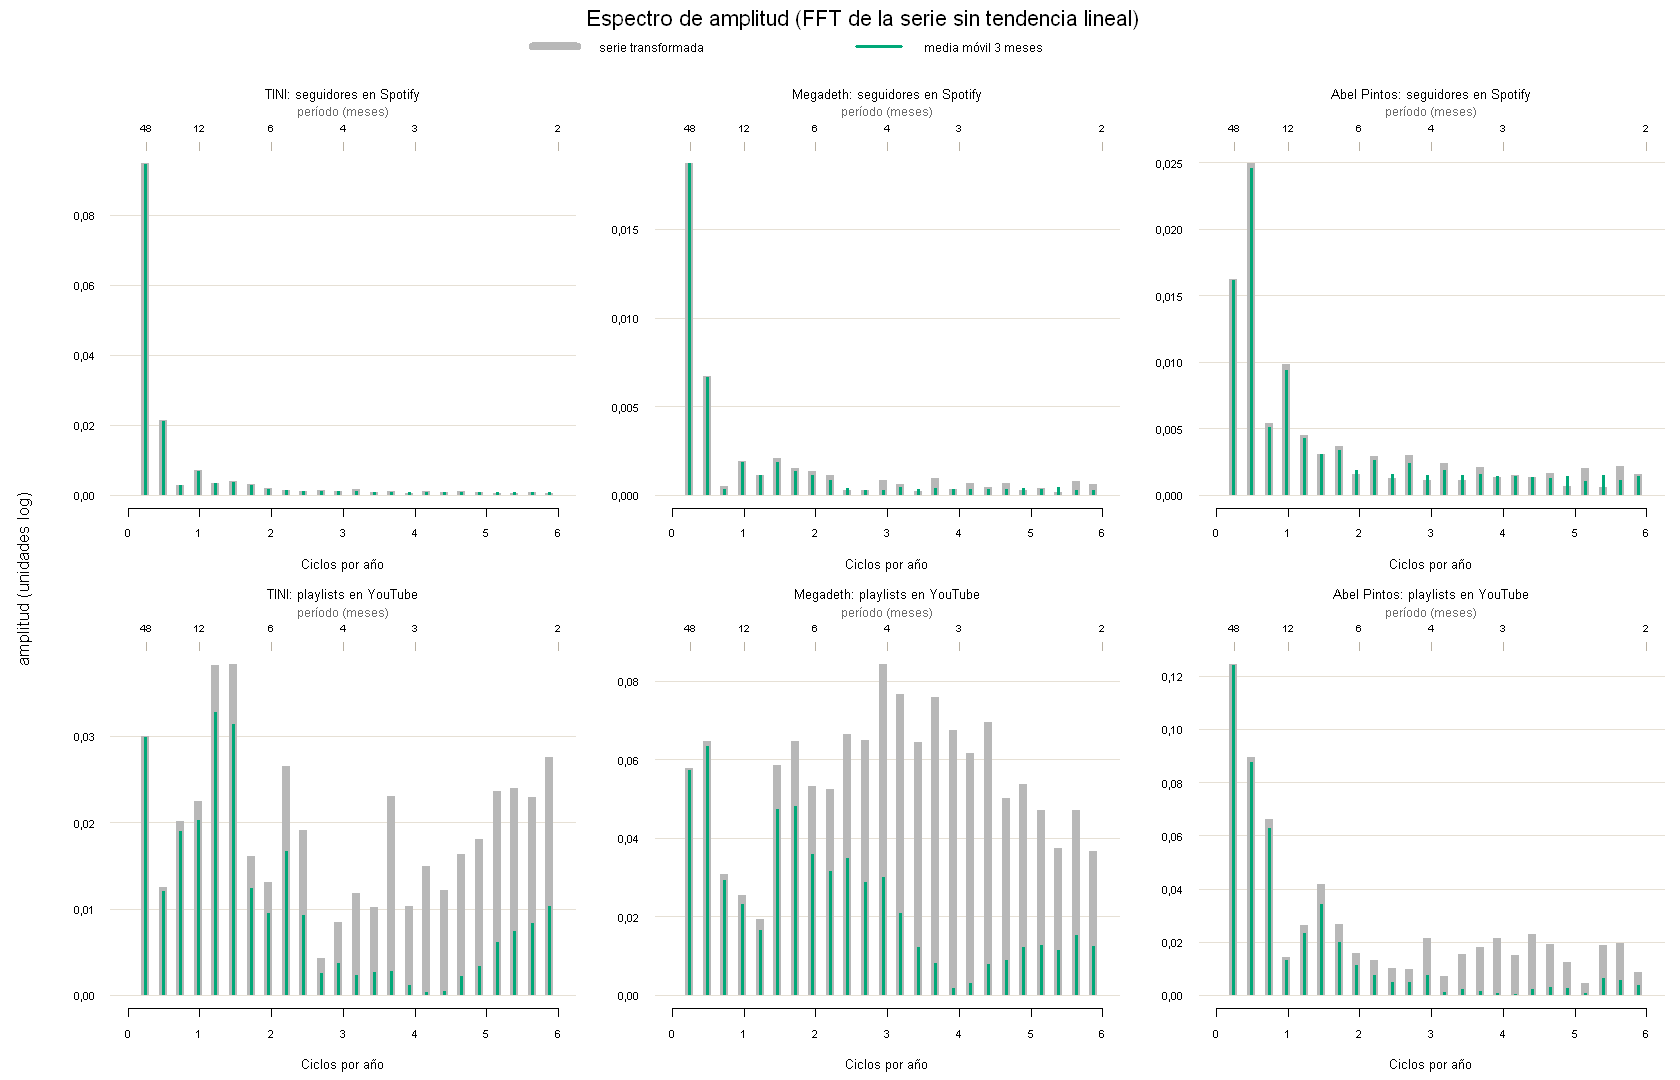

In [31]:
# ============================================================
# FIGURA 6: espectro de amplitud de los artistas ilustrativos,
# una variable lenta y una ruidosa
# ============================================================

VARIABLES_FIGURA_ESPECTRO <- c("spotify_followers", "youtube_playlist_count")

grafico_espectro_amplitud <- function() {

  par(mfrow = c(length(VARIABLES_FIGURA_ESPECTRO), length(ids_ilustrativos)), bg = COLOR_FONDO,
      mar = c(4.5, 4, 4.5, 1), oma = c(0, 3, 5, 0), las = 1, cex.axis = 0.85)

  for (variable_figura in VARIABLES_FIGURA_ESPECTRO) {
    for (i in seq_along(ids_ilustrativos)) {

      espectro_artista <- espectro_panel[artist_id == ids_ilustrativos[i] & variable == variable_figura]

      plot(espectro_artista$ciclos_por_anio, espectro_artista$amplitud_transformada,
           type = "n", bty = "n", xlab = "Ciclos por año", ylab = "", yaxt = "n",
           ylim = c(0, max(espectro_artista$amplitud_transformada)), xlim = c(0, 6))
      marcas_y <- axTicks(2)
      axis(2, at = marcas_y, labels = format(marcas_y, decimal.mark = ","), col = NA)
      abline(h = marcas_y, col = COLOR_GRILLA)

      # eje superior: periodo de la oscilacion en meses
      periodos_meses <- c(48, 12, 6, 4, 3, 2)
      axis(3, at = 12 / periodos_meses, labels = periodos_meses, col = NA, col.ticks = "#B8B0A2", cex.axis = 0.75)
      mtext("período (meses)", side = 3, line = 2, cex = 0.6, col = "#6B6B6B")

      segments(espectro_artista$ciclos_por_anio, 0, espectro_artista$ciclos_por_anio,
               espectro_artista$amplitud_transformada, col = COLOR_SERIE_BASE, lwd = 7, lend = 1)
      segments(espectro_artista$ciclos_por_anio, 0, espectro_artista$ciclos_por_anio,
               espectro_artista$amplitud_suavizada, col = COLOR_MEDIA_MOVIL, lwd = 2.5, lend = 1)

      title(paste0(artistas_ilustrativos$artist_name[i], ": ", en_minuscula_inicial(VARIABLES_PANEL[[variable_figura]])),
            font.main = 1, cex.main = 1, line = 3.3)
    }
  }

  mtext("Espectro de amplitud (FFT de la serie sin tendencia lineal)", side = 3, outer = TRUE, line = 3.2, cex = 1.1)
  mtext("amplitud (unidades log)", side = 2, outer = TRUE, line = 1, las = 0, cex = 0.85)

  par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
  plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
  legend("top", horiz = TRUE, bty = "n", inset = c(0, 0.025), cex = 0.9, lwd = c(7, 2.5),
         col = c(COLOR_SERIE_BASE, COLOR_MEDIA_MOVIL),
         legend = c("serie transformada", paste0("media móvil ", VENTANAS_MEDIA_MOVIL[["suavizado"]], " meses")))
}

guardar_figura("prepro_06_espectro_amplitud.png", grafico_espectro_amplitud, ancho = 2800, alto = 1800)

En los seguidores de Spotify casi toda la amplitud está en los primeros armónicos: la trayectoria es una forma lenta, de un año o más. En las playlists de YouTube hay amplitud también en las frecuencias altas, y la media móvil de 3 meses la recorta sin tocar las bajas. La tabla resume lo mismo para todo el panel: la proporción de la energía (amplitud al cuadrado) en oscilaciones de un año o más y en oscilaciones de menos de 6 meses.

In [32]:
# ------------------------------------------------------------
# ENERGIA POR BANDA DE FRECUENCIA, MEDIANA POR VARIABLE (%)
# (las series constantes no tienen energia y quedan fuera)
# ------------------------------------------------------------

espectro_panel[
  ,
  .(lenta_transformada = sum(amplitud_transformada[ciclos_por_anio <= 1]^2) / sum(amplitud_transformada^2),
    rapida_transformada = sum(amplitud_transformada[ciclos_por_anio > 2]^2) / sum(amplitud_transformada^2),
    rapida_suavizada = sum(amplitud_suavizada[ciclos_por_anio > 2]^2) / sum(amplitud_transformada^2)),
  by = .(artist_id, variable)
][
  ,
  lapply(.SD, function(x) round(100 * median(x, na.rm = TRUE), 1)),
  by = variable,
  .SDcols = c("lenta_transformada", "rapida_transformada", "rapida_suavizada")
]

variable,lenta_transformada,rapida_transformada,rapida_suavizada
<chr>,<dbl>,<dbl>,<dbl>
instagram_followers,91.5,3.4,1.5
spotify_followers,94.2,2.4,1.4
spotify_playlist_count,90.0,6.3,2.4
youtube_channel_subscribers,92.6,3.3,1.4
youtube_playlist_count,66.4,17.5,2.9


**Respuesta en frecuencia de los filtros.** La FFT de los coeficientes de un filtro muestra cuánto deja pasar de cada frecuencia (1 = intacta, 0 = eliminada). La línea en 0,7 marca el corte habitual.

**Pasa-bajos FFT.** El filtro de las clases 02 y 04 (FFT, máscara, FFT inversa) aplicado a un artista ilustrativo, conservando los primeros armónicos. La comparación con y sin restar la tendencia muestra en el tiempo el problema de bordes descripto arriba.

In [33]:
# ============================================================
# RESPUESTA EN FRECUENCIA DE LAS MEDIAS MOVILES Y PASA-BAJOS FFT
# ============================================================

# Coeficientes de cada filtro completados con ceros hasta un largo
# grande, para obtener una curva continua de |H(f)|
LARGO_RESPUESTA_FRECUENCIA <- 1200

respuesta_en_frecuencia <- function(coeficientes) {
  Mod(fft(c(coeficientes, rep(0, LARGO_RESPUESTA_FRECUENCIA - length(coeficientes)))))[
    1:(LARGO_RESPUESTA_FRECUENCIA %/% 2 + 1)
  ]
}

respuesta_filtros <- data.table(
  ciclos_por_anio = (0:(LARGO_RESPUESTA_FRECUENCIA %/% 2)) * 12 / LARGO_RESPUESTA_FRECUENCIA,
  suavizado = respuesta_en_frecuencia(rep(1 / VENTANAS_MEDIA_MOVIL[["suavizado"]], VENTANAS_MEDIA_MOVIL[["suavizado"]])),
  tendencia = respuesta_en_frecuencia(c(0.5, rep(1, VENTANAS_MEDIA_MOVIL[["tendencia"]] - 1), 0.5) / VENTANAS_MEDIA_MOVIL[["tendencia"]])
)

# Frecuencia donde cada filtro cae por debajo de 0,7
cortes_media_movil <- respuesta_filtros[
  , .(corte_suavizado = ciclos_por_anio[which(suavizado < 0.7)[1]],
      corte_tendencia = ciclos_por_anio[which(tendencia < 0.7)[1]])
]

cortes_media_movil

# Mascara pasa-bajos que conserva la frecuencia cero, los primeros
# armonicos y su espejo (indices N - k + 1)
filtro_pasa_bajos_fft <- function(x, banda = BANDA_FILTRO_PASA_BAJOS, quitar_tendencia = TRUE) {
  largo_serie <- length(x)
  recta <- if (quitar_tendencia) fitted(lm(x ~ seq_along(x))) else rep(0, largo_serie)
  mascara <- rep(0, largo_serie)
  mascara[1:(banda + 1)] <- 1
  mascara[(largo_serie - banda + 1):largo_serie] <- 1
  Re(fft(mascara * fft(x - recta), inverse = TRUE) / largo_serie) + recta
}

# Artista foco: el ilustrativo con mayor amplitud de trayectoria
artista_foco <- amplitud_series[
  artist_id %in% ids_ilustrativos & variable == VARIABLE_ILUSTRATIVA
][which.max(amplitud), artist_id]

serie_foco <- panel_long[.(artista_foco, VARIABLE_ILUSTRATIVA)]
serie_foco_pasa_bajos <- filtro_pasa_bajos_fft(serie_foco$valor_transformado)
serie_foco_pasa_bajos_sin_quitar_tendencia <- filtro_pasa_bajos_fft(serie_foco$valor_transformado, quitar_tendencia = FALSE)

corte_suavizado,corte_tendencia
<dbl>,<dbl>
1.89,0.45


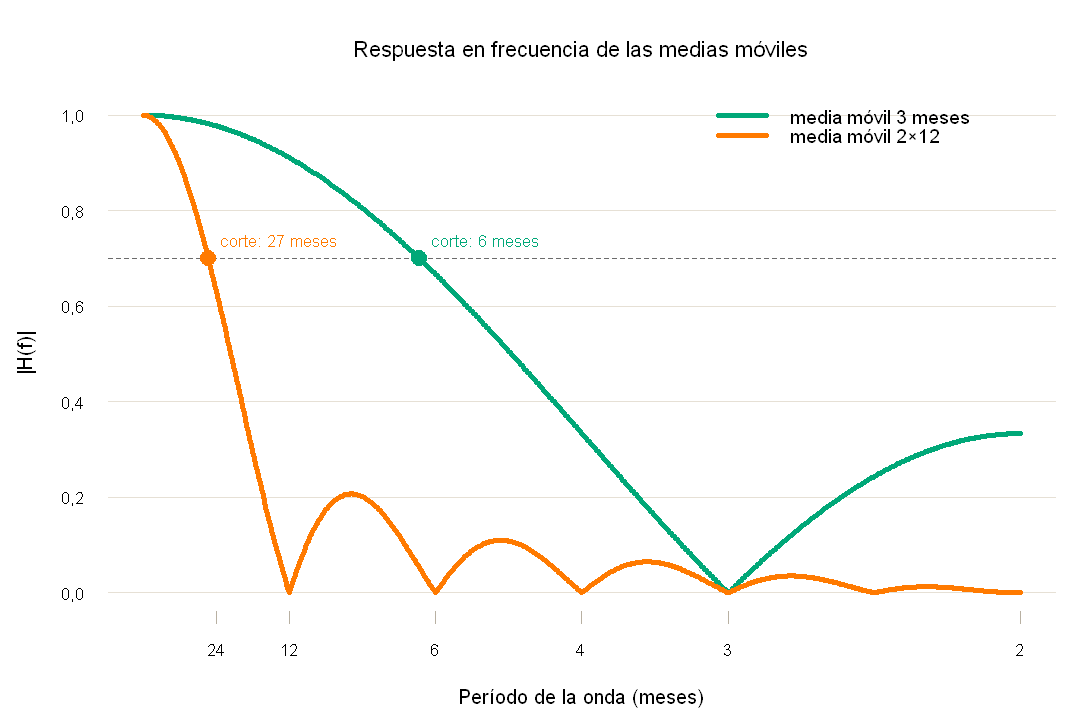

In [34]:
# ============================================================
# FIGURA 7: respuesta en frecuencia de las medias moviles, con el
# eje en periodo de la onda (meses)
# ============================================================

PERIODOS_EJE_RESPUESTA <- c(24, 12, 6, 4, 3, 2)

grafico_respuesta_medias_moviles <- function() {

  par(bg = COLOR_FONDO, mar = c(4.5, 4.5, 4, 1), las = 1, cex.axis = 0.85)

  plot(respuesta_filtros$ciclos_por_anio, respuesta_filtros$suavizado, type = "n", bty = "n",
       ylim = c(0, 1), xlab = "Período de la onda (meses)", ylab = "|H(f)|", xaxt = "n", yaxt = "n",
       main = "Respuesta en frecuencia de las medias móviles", font.main = 1, cex.main = 1.1)
  # posiciones en ciclos por anio, etiquetas en meses (periodo = 12 / ciclos por anio)
  axis(1, at = 12 / PERIODOS_EJE_RESPUESTA, labels = PERIODOS_EJE_RESPUESTA, col = NA, col.ticks = "#B8B0A2")
  axis(2, at = seq(0, 1, 0.2), labels = format(seq(0, 1, 0.2), decimal.mark = ","), col = NA)
  abline(h = seq(0, 1, 0.2), col = COLOR_GRILLA)
  abline(h = 0.7, lty = 2, col = COLOR_REFERENCIA)
  lines(respuesta_filtros$ciclos_por_anio, respuesta_filtros$suavizado, col = COLOR_MEDIA_MOVIL, lwd = 4)
  lines(respuesta_filtros$ciclos_por_anio, respuesta_filtros$tendencia, col = COLOR_TENDENCIA, lwd = 4)

  # corte de cada filtro en 0,7, expresado como periodo
  frecuencias_corte <- unlist(cortes_media_movil[, .(corte_suavizado, corte_tendencia)])
  points(frecuencias_corte, c(0.7, 0.7), pch = 19, cex = 1.8, col = c(COLOR_MEDIA_MOVIL, COLOR_TENDENCIA))
  text(frecuencias_corte, c(0.7, 0.7) + 0.035, pos = 4, cex = 0.85, col = c(COLOR_MEDIA_MOVIL, COLOR_TENDENCIA),
       labels = paste0("corte: ", round(12 / frecuencias_corte), " meses"))

  legend("topright", bty = "n", cex = 0.95, lwd = 4, col = c(COLOR_MEDIA_MOVIL, COLOR_TENDENCIA),
         legend = c(paste0("media móvil ", VENTANAS_MEDIA_MOVIL[["suavizado"]], " meses"),
                    paste0("media móvil 2×", VENTANAS_MEDIA_MOVIL[["tendencia"]])))
}

guardar_figura("prepro_07_respuesta_medias_moviles.png", grafico_respuesta_medias_moviles, ancho = 1800, alto = 1200)


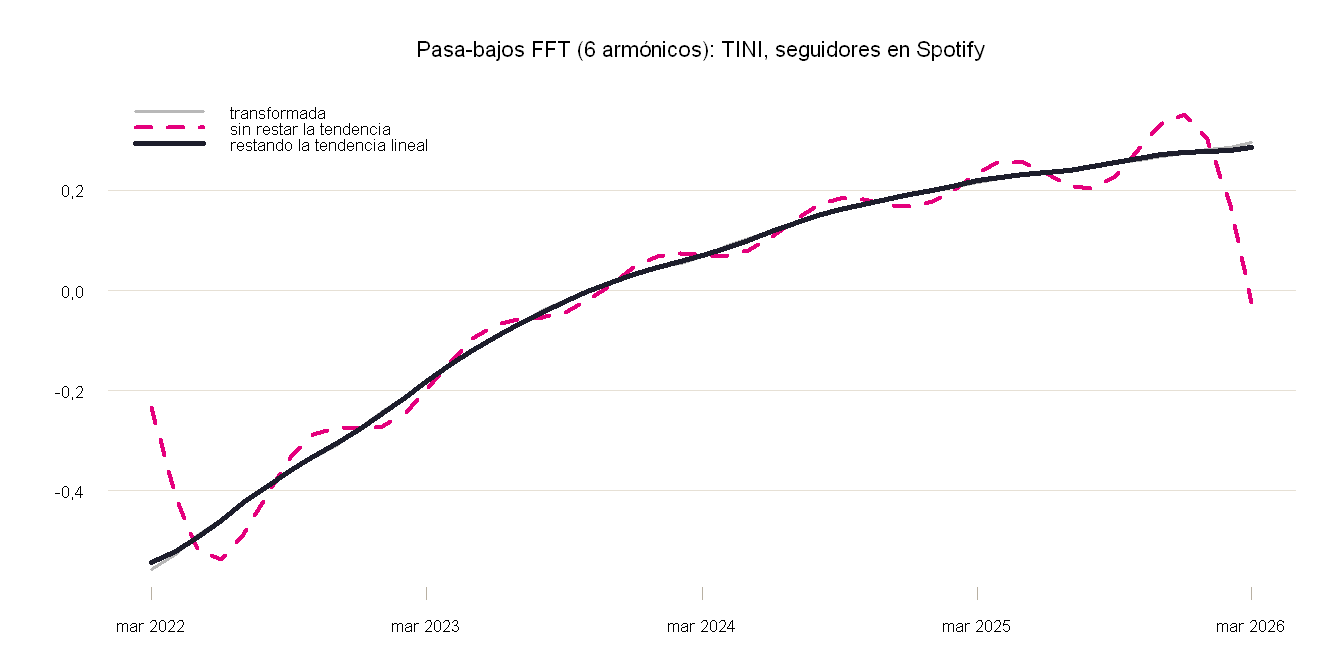

In [35]:
# ============================================================
# FIGURA 8: pasa-bajos FFT sobre el artista foco, con y sin
# restar la tendencia lineal
# ============================================================

grafico_pasa_bajos_fft <- function(
  serie = serie_foco,
  pasa_bajos = serie_foco_pasa_bajos,
  pasa_bajos_sin_restar = serie_foco_pasa_bajos_sin_quitar_tendencia,
  colores = c(transformada = COLOR_SERIE_BASE, sin_restar = COLOR_ALERTA, restando = COLOR_RESULTADO)
) {

  par(bg = COLOR_FONDO, mar = c(3, 4.5, 4, 1), las = 1, cex.axis = 0.85)

  abrir_lienzo(range(c(serie$valor_transformado, pasa_bajos_sin_restar)),
               paste0("Pasa-bajos FFT (", BANDA_FILTRO_PASA_BAJOS, " armónicos): ", serie$artist_name[1], ", ",
                      en_minuscula_inicial(VARIABLES_PANEL[[VARIABLE_ILUSTRATIVA]])))
  lines(serie$month, serie$valor_transformado, col = colores[["transformada"]], lwd = 2.5)
  lines(serie$month, pasa_bajos_sin_restar, col = colores[["sin_restar"]], lwd = 3.5, lty = 2)
  lines(serie$month, pasa_bajos, col = colores[["restando"]], lwd = 4)
  legend("topleft", bty = "n", cex = 0.85, lwd = c(2.5, 3.5, 4), lty = c(1, 2, 1), seg.len = 2.5,
         col = colores[c("transformada", "sin_restar", "restando")],
         legend = c("transformada", "sin restar la tendencia", "restando la tendencia lineal"))
}

guardar_figura("prepro_08_pasa_bajos_fft.png", grafico_pasa_bajos_fft, ancho = 2200, alto = 1100)


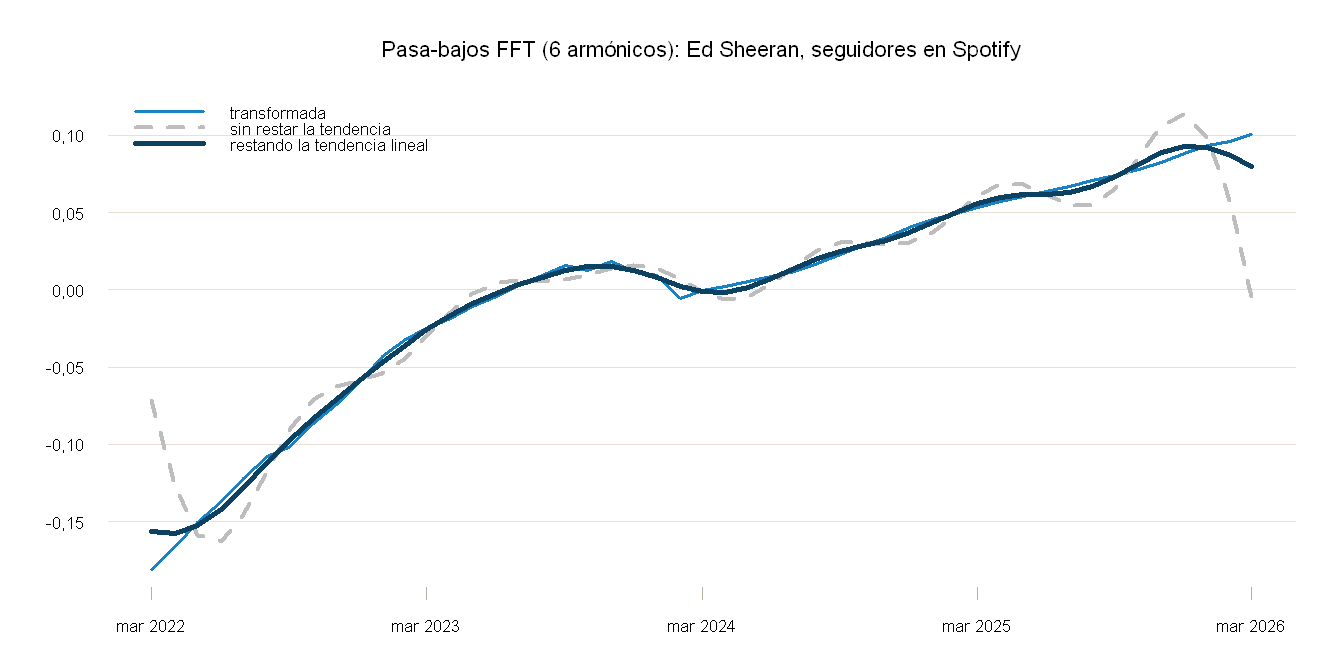

In [36]:
# ============================================================
# FIGURA 8, VERSION EN TONOS DEL ARTISTA: el pasa-bajos FFT sobre
# el artista de la version en tonos de la figura 5: transformada
# en su color propio, alternativa sin restar la tendencia en el
# gris claro de la figura 5 y resultado en el tono oscuro
# ============================================================

serie_version_tonos <- panel_long[.(ARTISTA_VERSION_TONOS, VARIABLE_ILUSTRATIVA)]

guardar_figura(
  paste0("prepro_08_pasa_bajos_fft_", SUFIJO_VERSION_TONOS, ".png"),
  function() grafico_pasa_bajos_fft(
    serie = serie_version_tonos,
    pasa_bajos = filtro_pasa_bajos_fft(serie_version_tonos$valor_transformado),
    pasa_bajos_sin_restar = filtro_pasa_bajos_fft(serie_version_tonos$valor_transformado, quitar_tendencia = FALSE),
    colores = c(transformada = TONOS_VERSION_ARTISTA[["propio"]],
                sin_restar = COLOR_MEDIA_MOVIL_VERSION_TONOS,
                restando = TONOS_VERSION_ARTISTA[["oscuro"]])
  ),
  ancho = 2200, alto = 1100
)


La media móvil de 3 meses deja pasar casi intactas las oscilaciones de más de medio año y atenúa las más rápidas. La 2×12 solo deja pasar las de más de dos años, aproximadamente, y se anula en 1, 2, 3... ciclos por año, lo que elimina cualquier estacionalidad anual: por eso funciona como tendencia. En el pasa-bajos FFT, sin restar la tendencia la reconstrucción se deforma en los extremos, porque la FFT obliga a que el último mes empalme con el primero.

## 9. Crecimiento mensual

La derivada FIR de tres muestras, `filter(x, c(0.5, 0, -0.5))`, aplicada a la serie suavizada mide el cambio mensual centrado. Con la transformación `log1p` equivale a la tasa de crecimiento mensual (0,01 es aproximadamente 1 %). Es un filtro pasa-altos: por eso se aplica sobre la serie ya suavizada. En el primer y el último mes se usa la diferencia hacia un solo lado. Es el insumo de la segmentación.

In [37]:
# ============================================================
# DERIVADA FIR: CRECIMIENTO MENSUAL
# ============================================================

derivada_fir_centrada <- function(x) {
  largo_serie <- length(x)
  derivada <- as.numeric(stats::filter(x, c(0.5, 0, -0.5), sides = 2))
  derivada[1] <- x[2] - x[1]
  derivada[largo_serie] <- x[largo_serie] - x[largo_serie - 1]
  derivada
}

panel_long[
  ,
  crecimiento_mensual := derivada_fir_centrada(valor_suavizado),
  by = .(artist_id, variable)
]

In [38]:
# ------------------------------------------------------------
# CONTROL: crecimiento mensual tipico por variable, y el mes de
# mayor crecimiento de los artistas de la figura de presentacion
# ------------------------------------------------------------

panel_long[
  ,
  .(mediana_pct = round(100 * median(crecimiento_mensual), 2),
    p95_pct = round(100 * quantile(crecimiento_mensual, 0.95), 2)),
  by = variable
]

panel_long[
  artist_id %in% ARTISTAS_FIGURA_PRESENTACION,
  .SD[which.max(crecimiento_mensual), .(month, crecimiento_pct = round(100 * crecimiento_mensual, 1))],
  by = .(artist_name, variable)
]

variable,mediana_pct,p95_pct
<chr>,<dbl>,<dbl>
instagram_followers,0.50,4.55
spotify_followers,0.96,4.65
spotify_playlist_count,1.73,4.81
youtube_channel_subscribers,0.58,3.26
youtube_playlist_count,0.00,10.13


artist_name,variable,month,crecimiento_pct
<chr>,<chr>,<date>,<dbl>
Ed Sheeran,instagram_followers,2022-05-01,1.4
Ed Sheeran,spotify_followers,2022-03-01,1.5
Ed Sheeran,spotify_playlist_count,2023-05-01,3.5
Ed Sheeran,youtube_channel_subscribers,2025-06-01,1.1
Ed Sheeran,youtube_playlist_count,2023-10-01,5.7
Peso Pluma,instagram_followers,2023-02-01,51.6
Peso Pluma,spotify_followers,2022-09-01,56.4
Peso Pluma,spotify_playlist_count,2023-04-01,40.6
Peso Pluma,youtube_channel_subscribers,2023-03-01,95.4


## 10. Exportación

El panel preprocesado conserva la serie cruda y las marcas de cada etapa (pico aislado, celda imputada, mes empalmado, flag de interpolación de Chartmetric), de modo que cualquier resultado posterior pueda rastrearse hasta el dato original. El nombre del archivo incluye la transformación usada.

In [39]:
# ============================================================
# EXPORTACION DEL PANEL PREPROCESADO
# ============================================================

fwrite(
  panel_long[
    ,
    .(artist_id, artist_name, cm_artist_rank, decil_marco, variable, month,
      valor_crudo, interpolated, pico_aislado, imputado, empalme, log_valor,
      valor_transformado, valor_suavizado, tendencia, crecimiento_mensual)
  ],
  ARCHIVO_PANEL_PREPROCESADO
)

cat("Exportado:", ARCHIVO_PANEL_PREPROCESADO, "\n",
    "Filas:", nrow(panel_long), "\n")

Exportado: artistas_ST_1098de1510_top5000_22_26_preprocesado_log1p_centrado_long.csv 
 Filas: 265335 
